# 09 — Cooling ML Model Analysis & Optimization (75-Feature Baseline)

**Goal**: Analyze the LightGBM overheating classifier with the full 75-feature set,
compare F1 vs F2 threshold selection, prune, tune, evaluate regression alternative,
and explore a dual-output approach (regression intensity + classifier gate).

**Baseline**: 75 features, AUC=0.9771, threshold=0.0494 (F2-selected, isotonic-calibrated)

**Training data**: `Logs_and_models/cooling_training_data.csv.gz` (47,941 rows × 76 cols)

**Key change**: Switching from F2 (β=2, recall-biased → threshold≈0.01) to F1 (balanced precision/recall).

In [1]:
import sys, os, json, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

ROOT = Path(os.getcwd())
while not (ROOT / 'Logs_and_models').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
print(f'Project root: {ROOT}')

DATA_PATH = ROOT / 'Logs_and_models' / 'cooling_training_data.csv.gz'
META_PATH = ROOT / 'Logs_and_models' / 'cooling_ml_metadata.json'

with open(META_PATH) as f:
    meta = json.load(f)

# Support both old (val_f2) and new (val_f1) metadata keys
val_f_key = 'val_f1' if 'val_f1' in meta else 'val_f2'
val_f_score = meta[val_f_key]

print(f"Metadata: {meta['n_features']} features, AUC={meta['roc_auc']:.4f}, "
      f"{val_f_key}={val_f_score:.4f}, threshold={meta['threshold']:.4f}")
print(f"Label horizon: {meta['label_horizon_h']}h, Forecast horizon: {meta['forecast_horizon_h']}h")
print(f"Cooling target: {meta['cooling_target_c']}°C")
print(f"Calibrated: {meta.get('calibrated', False)}, Method: {meta.get('threshold_method', 'unknown')}")

Project root: c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor
Metadata: 75 features, AUC=0.9771, val_f2=0.9472, threshold=0.0494
Label horizon: 8h, Forecast horizon: 12h
Cooling target: 23.0°C
Calibrated: True, Method: f2_cross_validated


## Section 1: Data Loading & EDA

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nLabel distribution:')
print(df['label'].value_counts())
print(f'Positive rate: {df["label"].mean():.1%}')
print(f'\nNaN summary:')
nan_pct = df.isna().mean() * 100
print(nan_pct[nan_pct > 0].sort_values(ascending=False).to_string() if nan_pct.max() > 0 else 'No NaN values')
df.describe().round(3)

Shape: (47941, 76)
Columns: ['indoor_temp', 'indoor_margin', 'indoor_trend_30m', 'indoor_trend_1h', 'AT', 'at_delta_indoor', 'AT_roh_1h', 'AT_roh_2h', 'AT_roh_3h', 'AT_roh_4h', 'AT_roh_5h', 'AT_roh_6h', 'AT_roh_7h', 'AT_roh_8h', 'AT_roh_9h', 'AT_roh_10h', 'AT_roh_11h', 'AT_roh_12h', 'PV_Generate', 'pv_roll_1h', 'pv_roll_2h', 'pv_forecast_1h', 'pv_forecast_2h', 'pv_forecast_3h', 'pv_forecast_4h', 'pv_forecast_5h', 'pv_forecast_6h', 'pv_forecast_7h', 'pv_forecast_8h', 'pv_forecast_9h', 'pv_forecast_10h', 'pv_forecast_11h', 'pv_forecast_12h', 'thermal_power_kw', 'delta_t', 'outlet_indoor_diff', 'VLT', 'RLT', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'wind_speed', 'living_room_temp', 'fireplace_on', 'tv_on', 'fireplace_lag_30m', 'fireplace_lag_1h', 'fireplace_lag_2h', 'tv_lag_30m', 'tv_lag_1h', 'heat_loss_driving_force', 'indoor_temp_gradient', 'indoor_margin_rate', 'delta_T_indoor_lag1', 'd_inlet_temp_60min', 'is_equilibrium', 'thermal_power_rolling_1h', 'is_overshoot', 'is_hp_active'

,indoor_temp,indoor_margin,indoor_trend_30m,indoor_trend_1h,AT,at_delta_indoor,AT_roh_1h,AT_roh_2h,AT_roh_3h,AT_roh_4h,...,cum_at_excess_4h,max_at_forecast,indoor_momentum,slab_stored_heat,traj_predicted_error,traj_convergence_rate,traj_reaches_target_hours,traj_overshoot_magnitude,traj_equilibrium_gap,label
count,47941.000,47941.000,47941.000,47941.000,47941.000,47941.000,47941.000,47941.000,47941.000,47941.000,...,47941.000,47941.000,47941.000,47941.000,47941.000,47941.000,47941.000,47941.000,47941.000,47941.000
mean,23.015,-0.015,-0.000,-0.000,17.295,-5.720,17.297,17.297,17.301,17.299,...,2.486,19.487,-0.000,0.056,-0.517,0.011,4.731,0.527,-0.643,0.656
std,0.438,0.438,0.064,0.100,7.518,7.465,7.526,7.531,7.539,7.550,...,12.468,15.885,0.299,2.108,1.646,0.035,3.404,1.094,2.046,0.475
min,20.520,-1.330,-1.200,-1.450,10.020,-13.802,9.103,8.548,8.195,8.408,...,0.000,10.315,-4.350,-146.985,-96.979,-1.741,0.000,0.000,-119.769,0.000
25%,22.756,-0.320,-0.010,-0.028,12.900,-9.990,12.930,12.920,12.943,12.958,...,0.000,14.753,-0.084,-0.810,-1.195,-0.002,1.013,0.000,-1.459,0.000
50%,23.020,-0.020,0.000,0.008,16.040,-6.890,16.089,16.102,16.116,16.114,...,0.000,18.262,0.024,0.230,-0.581,0.011,6.899,0.220,-0.724,1.000
75%,23.320,0.244,0.020,0.040,20.700,-2.340,20.718,20.715,20.716,20.726,...,0.000,22.923,0.120,1.120,0.162,0.025,8.000,0.620,0.170,1.000
max,24.330,2.480,0.848,0.858,839.230,815.700,839.396,838.855,838.981,839.977,...,829.312,839.977,2.574,7.260,86.746,1.924,8.000,107.368,107.368,1.000


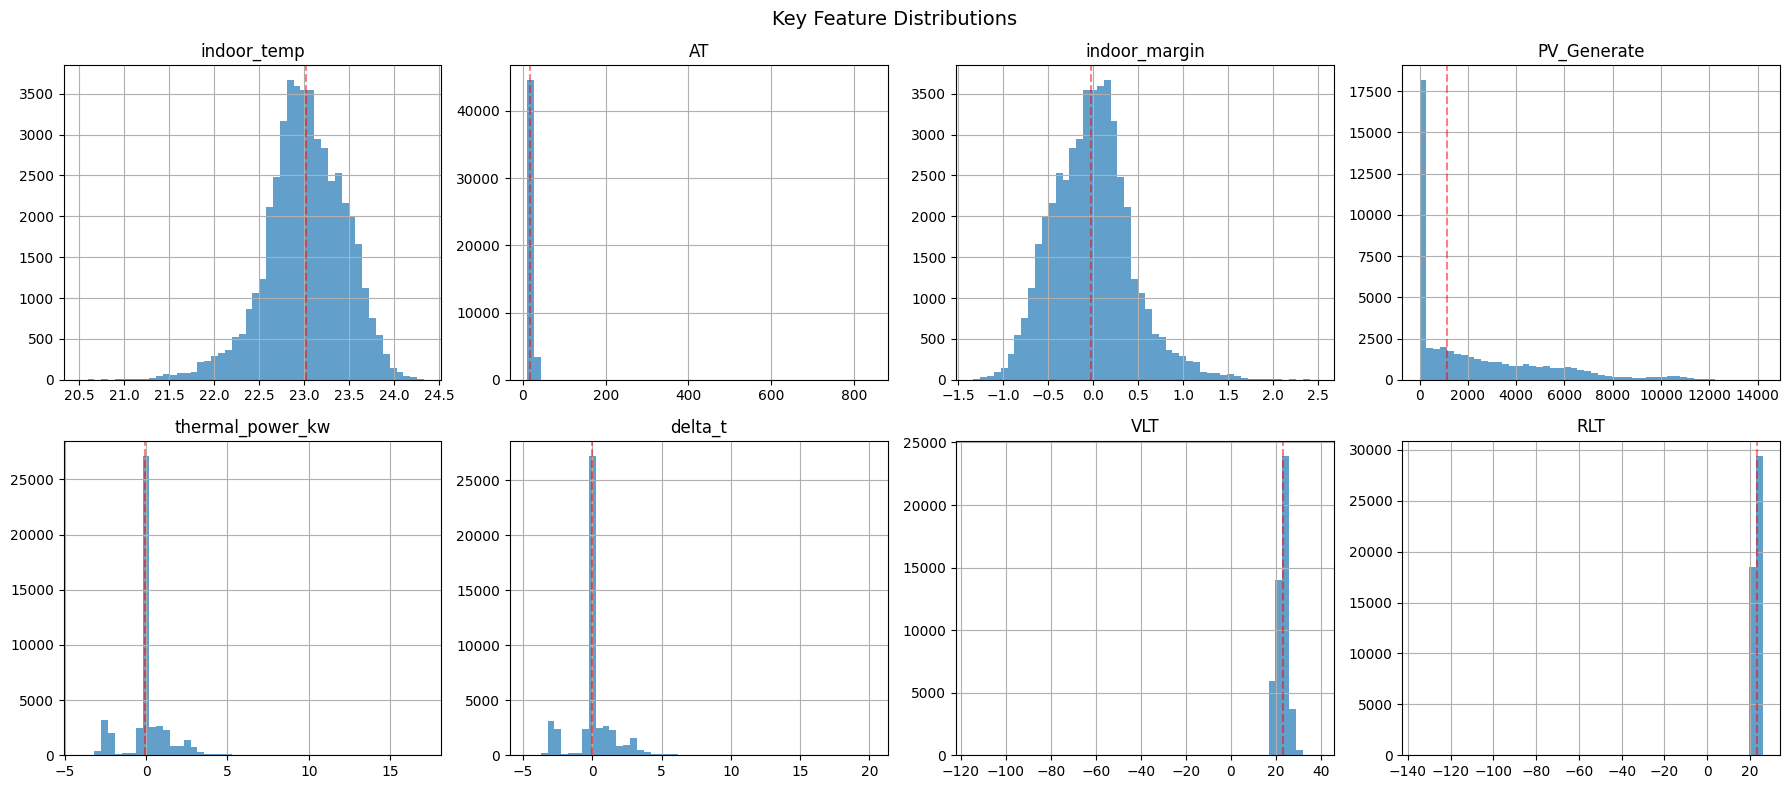

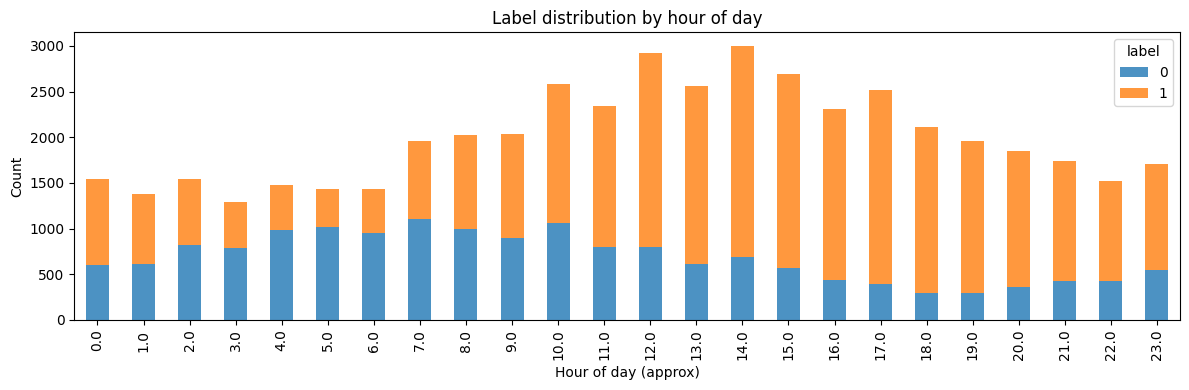

In [3]:
# Key feature distributions
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
key_cols = ['indoor_temp', 'AT', 'indoor_margin', 'PV_Generate',
            'thermal_power_kw', 'delta_t', 'VLT', 'RLT']
for ax, col in zip(axes.flat, key_cols):
    if col in df.columns:
        df[col].hist(bins=50, ax=ax, alpha=0.7)
        ax.set_title(col)
        ax.axvline(df[col].median(), color='r', ls='--', alpha=0.5)
plt.suptitle('Key Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

# Label by hour (if temporal features present)
if 'hour_sin' in df.columns and 'hour_cos' in df.columns:
    hour_approx = np.round(np.arctan2(df['hour_sin'], df['hour_cos']) * 24 / (2*np.pi)) % 24
    fig, ax = plt.subplots(figsize=(12, 4))
    pd.crosstab(hour_approx, df['label']).plot.bar(stacked=True, ax=ax, alpha=0.8)
    ax.set_xlabel('Hour of day (approx)')
    ax.set_ylabel('Count')
    ax.set_title('Label distribution by hour of day')
    plt.tight_layout()
    plt.show()

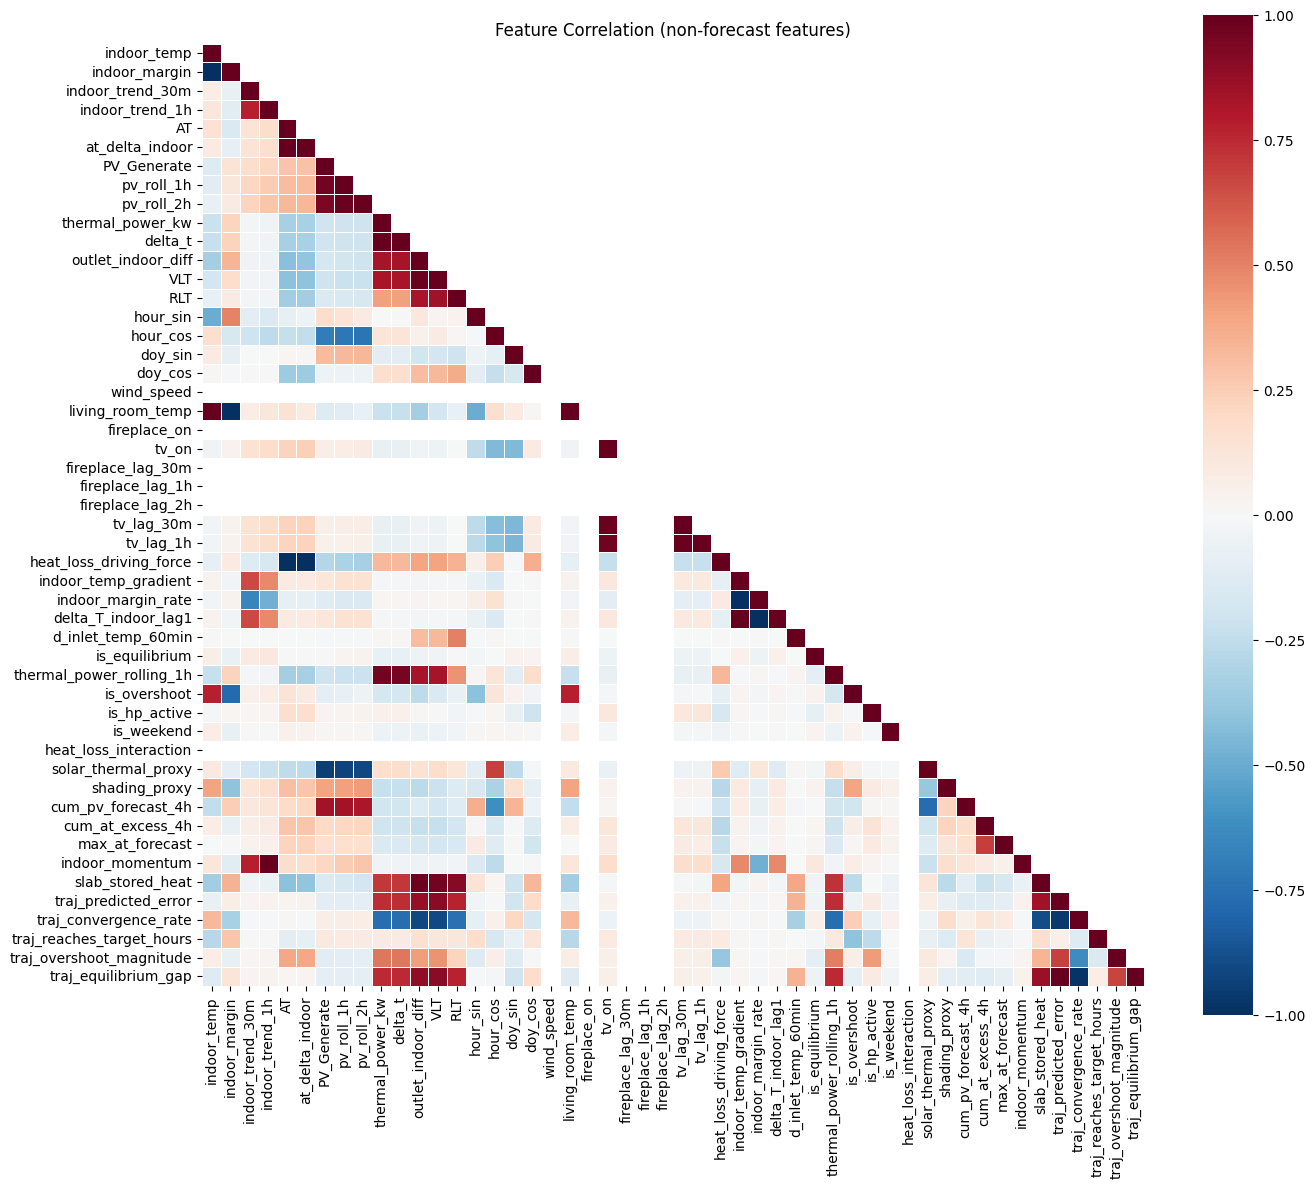

In [4]:
# Correlation heatmap of non-forecast features
non_fc = [c for c in df.columns if not c.startswith('AT_roh_') and not c.startswith('pv_forecast_') and c != 'label']
corr = df[non_fc].corr()
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax, fmt='.2f',
            annot=True if len(non_fc) <= 20 else False)
ax.set_title('Feature Correlation (non-forecast features)')
plt.tight_layout()
plt.show()

## Section 2: Baseline Classifier (75 features — F1 threshold)

In [5]:
import lightgbm as lgb
from sklearn.metrics import (
    roc_auc_score, f1_score, fbeta_score, precision_score, recall_score,
    confusion_matrix, classification_report, precision_recall_curve,
    roc_curve, average_precision_score
)
from sklearn.model_selection import TimeSeriesSplit

FEATURE_COLS_BASELINE = meta['feature_cols']
COOLING_TARGET = meta['cooling_target_c']
LABEL_HORIZON_H = meta['label_horizon_h']
STEPS_PER_HOUR = meta['steps_per_hour']

# Verify all baseline features exist in CSV
missing = [c for c in FEATURE_COLS_BASELINE if c not in df.columns]
print(f'Missing baseline features: {missing}' if missing else f'All {len(FEATURE_COLS_BASELINE)} baseline features present')

# Time-ordered train/val split (75/25)
val_frac = 0.25
n_val = max(1, int(len(df) * val_frac))
df_fit = df.iloc[:-n_val].copy()
df_val = df.iloc[-n_val:].copy()

X_fit = df_fit[FEATURE_COLS_BASELINE].values.astype(float)
y_fit = df_fit['label'].values.astype(int)
X_val = df_val[FEATURE_COLS_BASELINE].values.astype(float)
y_val = df_val['label'].values.astype(int)

print(f'Train: {len(df_fit)} rows ({y_fit.mean():.1%} pos), Val: {len(df_val)} rows ({y_val.mean():.1%} pos)')

All 75 baseline features present
Train: 35956 rows (62.6% pos), Val: 11985 rows (74.7% pos)


In [6]:
# Train baseline LightGBM classifier with all 75 features
lgb_params = meta['lgb_params'].copy()
lgb_params.pop('n_jobs', None)  # notebook: single-thread safe

baseline_model = lgb.LGBMClassifier(**lgb_params)
baseline_model.fit(X_fit, y_fit)

# Predict probabilities
y_proba_base = baseline_model.predict_proba(X_val)[:, 1]

# AUC
auc_base = roc_auc_score(y_val, y_proba_base)
print(f'Baseline AUC: {auc_base:.4f} (metadata: {meta["roc_auc"]:.4f})')

# F1-optimal threshold (balanced precision/recall)
def find_f1_threshold(y_true, y_proba, n_points=200):
    thresholds = np.linspace(0.01, 0.99, n_points)
    f1_scores = [f1_score(y_true, (y_proba >= t).astype(int)) for t in thresholds]
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx]

# Also keep F2 for comparison
def find_f2_threshold(y_true, y_proba, n_points=200):
    thresholds = np.linspace(0.01, 0.99, n_points)
    f2_scores = [fbeta_score(y_true, (y_proba >= t).astype(int), beta=2) for t in thresholds]
    best_idx = np.argmax(f2_scores)
    return thresholds[best_idx], f2_scores[best_idx]

thresh_base, f1_base = find_f1_threshold(y_val, y_proba_base)
y_pred_base = (y_proba_base >= thresh_base).astype(int)

print(f'F1-optimal threshold: {thresh_base:.4f} (metadata: {meta["threshold"]:.4f})')
print(f'F1 score: {f1_base:.4f}')
print(f'Precision: {precision_score(y_val, y_pred_base):.4f}')
print(f'Recall: {recall_score(y_val, y_pred_base):.4f}')
print(f'Predicted positive rate: {y_pred_base.mean():.1%} (true: {y_val.mean():.1%})')
print(f'\nConfusion Matrix:')
print(confusion_matrix(y_val, y_pred_base))
print(f'\n{classification_report(y_val, y_pred_base, target_names=["no_overheat", "overheat"])}')

Baseline AUC: 0.9434 (metadata: 0.9771)
F1-optimal threshold: 0.7733 (metadata: 0.0494)
F1 score: 0.9191
Precision: 0.9490
Recall: 0.8910
Predicted positive rate: 70.1% (true: 74.7%)

Confusion Matrix:
[[2610  428]
 [ 975 7972]]

              precision    recall  f1-score   support

 no_overheat       0.73      0.86      0.79      3038
    overheat       0.95      0.89      0.92      8947

    accuracy                           0.88     11985
   macro avg       0.84      0.88      0.85     11985
weighted avg       0.89      0.88      0.89     11985



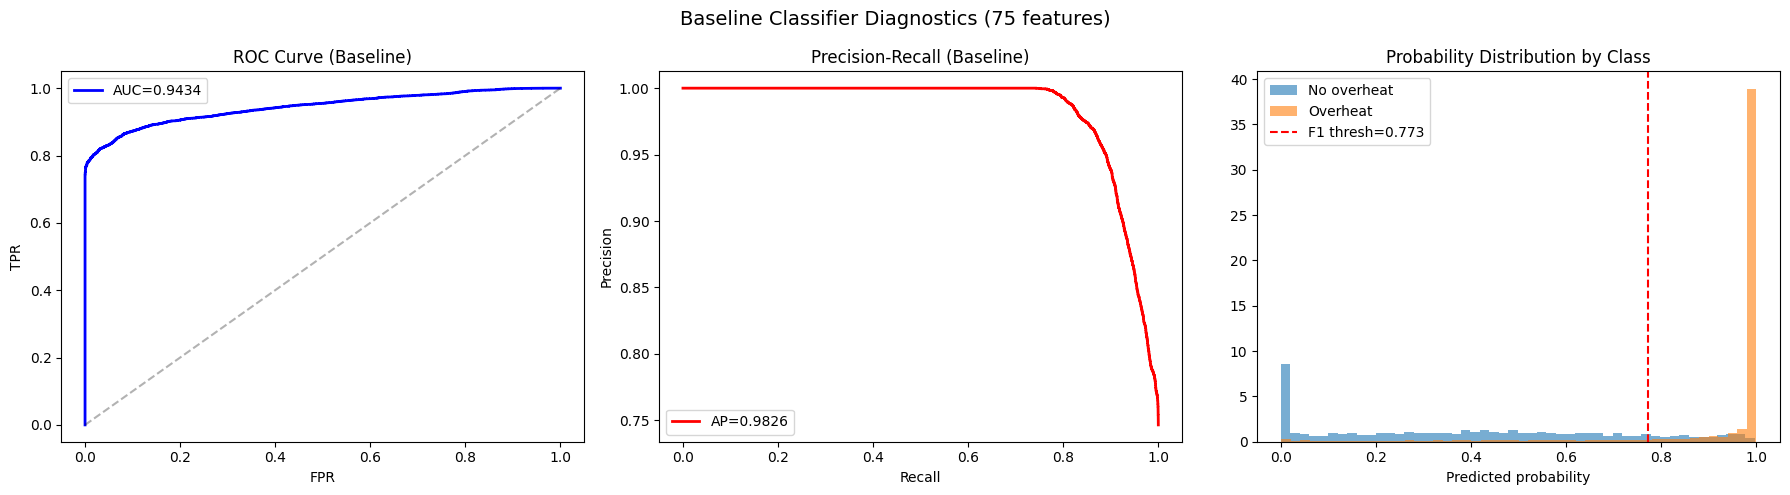

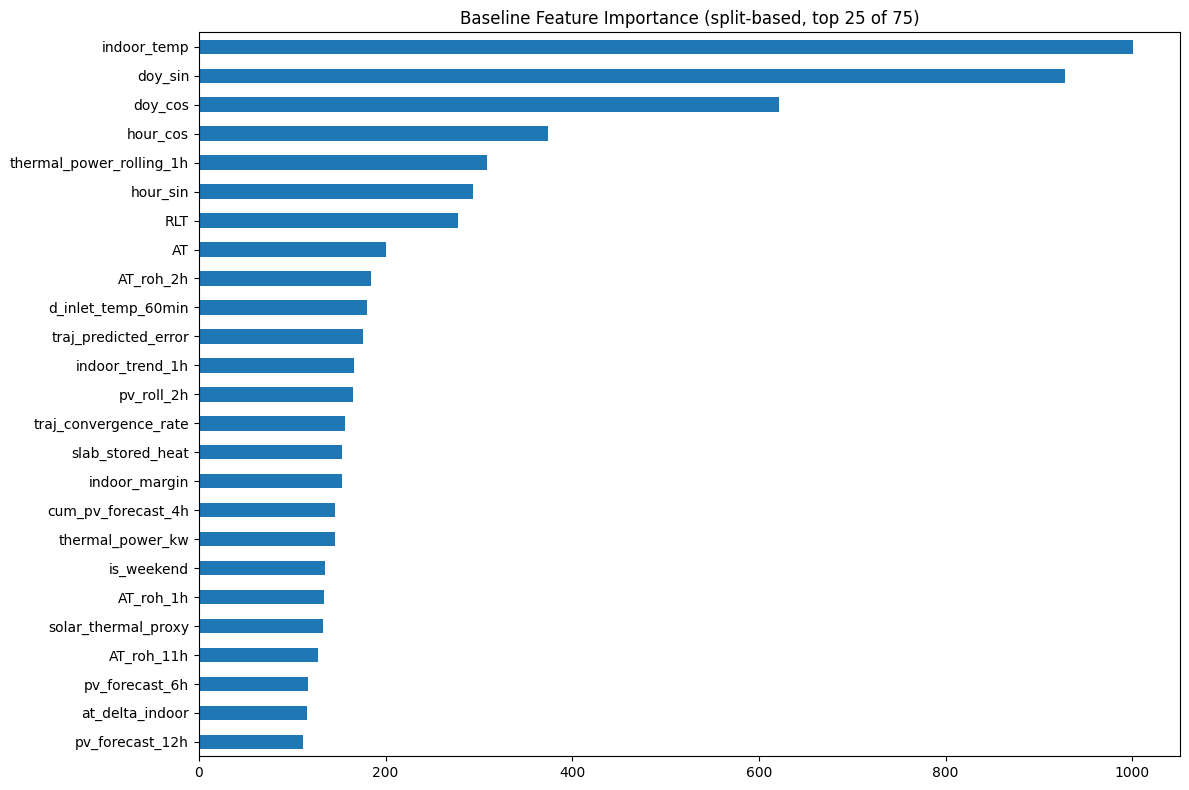

In [7]:
# Baseline diagnostic plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_val, y_proba_base)
axes[0].plot(fpr, tpr, 'b-', lw=2, label=f'AUC={auc_base:.4f}')
axes[0].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve (Baseline)')
axes[0].legend()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_val, y_proba_base)
ap = average_precision_score(y_val, y_proba_base)
axes[1].plot(rec, prec, 'r-', lw=2, label=f'AP={ap:.4f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall (Baseline)')
axes[1].legend()

# Probability distribution by class
axes[2].hist(y_proba_base[y_val==0], bins=50, alpha=0.6, label='No overheat', density=True)
axes[2].hist(y_proba_base[y_val==1], bins=50, alpha=0.6, label='Overheat', density=True)
axes[2].axvline(thresh_base, color='r', ls='--', label=f'F1 thresh={thresh_base:.3f}')
axes[2].set_xlabel('Predicted probability')
axes[2].set_title('Probability Distribution by Class')
axes[2].legend()

plt.suptitle(f'Baseline Classifier Diagnostics ({len(FEATURE_COLS_BASELINE)} features)', fontsize=14)
plt.tight_layout()
plt.show()

# Feature importance (top 25)
fi = pd.Series(baseline_model.feature_importances_, index=FEATURE_COLS_BASELINE).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 8))
fi.head(25).plot.barh(ax=ax)
ax.set_title(f'Baseline Feature Importance (split-based, top 25 of {len(FEATURE_COLS_BASELINE)})')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Threshold Diagnostic: F1 vs F2

The F2-optimal threshold is suspiciously low (0.010) — effectively predicting everything as positive.
This happens because F2 weights recall 4× more than precision, and the validation set is 74.8% positive.

Let's compare F1 (balanced) vs F2 (recall-biased) threshold selection and examine the
probability calibration to understand the root cause.

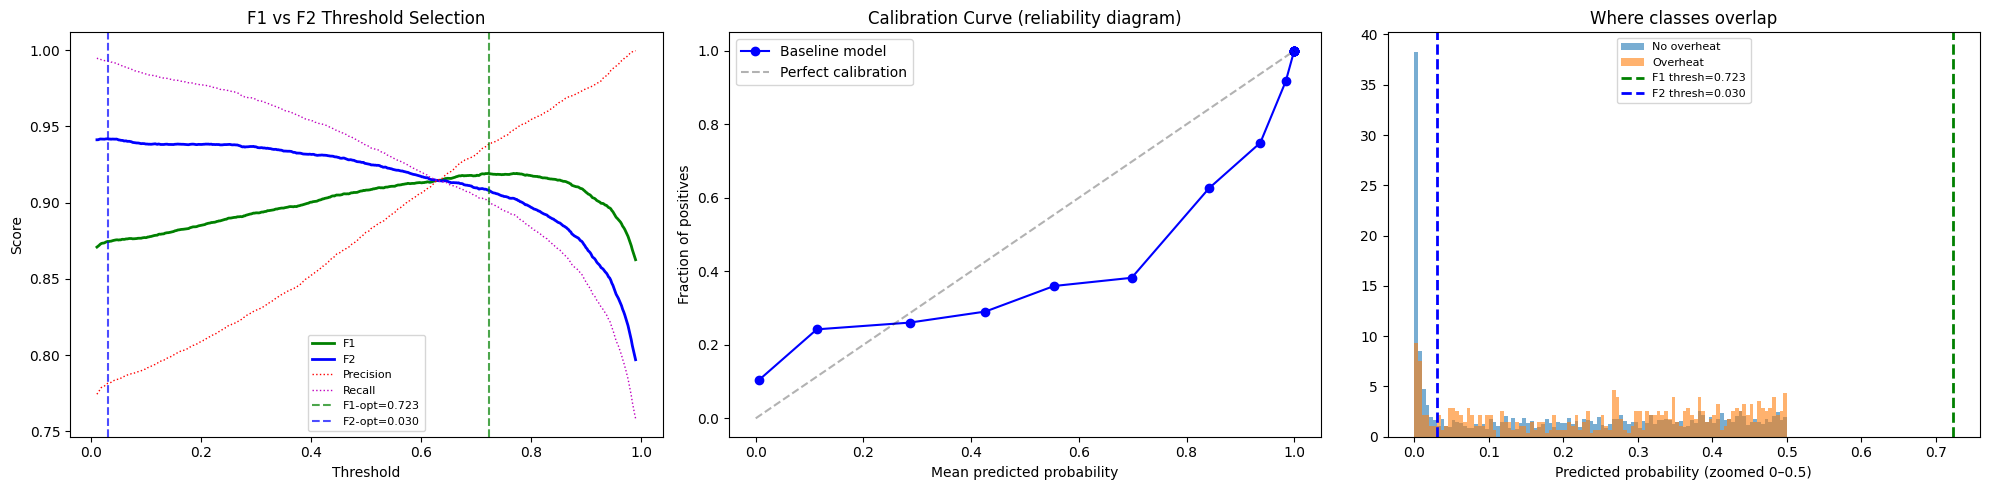

Metric                 F1-optimal   F2-optimal
Threshold                  0.7229       0.0296
F1                         0.9192       0.8746
F2                         0.9081       0.9418
Precision                  0.9383       0.7815
Recall                     0.9009       0.9927
Predicted pos rate          71.7%        94.8%
True pos rate               74.7%        74.7%

Confusion (F1-opt): 
[[2508  530]
 [ 887 8060]]

Confusion (F2-opt): 
[[ 555 2483]
 [  65 8882]]

--- Root Cause ---
Overheat samples with P < 0.1: 141/8947 (1.6%)
→ These are borderline cases the model is uncertain about.
→ F2 captures them (high recall), F1 ignores them (higher precision).
→ For safety (pre-cooling), F2 is appropriate BUT the threshold should 
   come from cross-validated F2 on time-series folds, not holdout.


In [8]:
# F1 vs F2 threshold comparison
thresholds_scan = np.linspace(0.01, 0.99, 500)
f1_scores = [f1_score(y_val, (y_proba_base >= t).astype(int)) for t in thresholds_scan]
f2_scores = [fbeta_score(y_val, (y_proba_base >= t).astype(int), beta=2) for t in thresholds_scan]
prec_scores = [precision_score(y_val, (y_proba_base >= t).astype(int), zero_division=0) for t in thresholds_scan]
rec_scores = [recall_score(y_val, (y_proba_base >= t).astype(int), zero_division=0) for t in thresholds_scan]

best_f1_idx = np.argmax(f1_scores)
best_f2_idx = np.argmax(f2_scores)
thresh_f1 = thresholds_scan[best_f1_idx]
thresh_f2 = thresholds_scan[best_f2_idx]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# F1 vs F2 score curves
axes[0].plot(thresholds_scan, f1_scores, 'g-', lw=2, label='F1')
axes[0].plot(thresholds_scan, f2_scores, 'b-', lw=2, label='F2')
axes[0].plot(thresholds_scan, prec_scores, 'r:', lw=1, label='Precision')
axes[0].plot(thresholds_scan, rec_scores, 'm:', lw=1, label='Recall')
axes[0].axvline(thresh_f1, color='g', ls='--', alpha=0.7, label=f'F1-opt={thresh_f1:.3f}')
axes[0].axvline(thresh_f2, color='b', ls='--', alpha=0.7, label=f'F2-opt={thresh_f2:.3f}')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('F1 vs F2 Threshold Selection')
axes[0].legend(fontsize=8)

# Probability calibration: predicted proba vs actual positive rate
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_val, y_proba_base, n_bins=20, strategy='quantile')
axes[1].plot(prob_pred, prob_true, 'bo-', label='Baseline model')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect calibration')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_ylabel('Fraction of positives')
axes[1].set_title('Calibration Curve (reliability diagram)')
axes[1].legend()

# Zoomed probability distribution (0–0.3 range where the action is)
axes[2].hist(y_proba_base[y_val==0], bins=100, alpha=0.6, label='No overheat', density=True, range=(0, 0.5))
axes[2].hist(y_proba_base[y_val==1], bins=100, alpha=0.6, label='Overheat', density=True, range=(0, 0.5))
axes[2].axvline(thresh_f1, color='g', ls='--', lw=2, label=f'F1 thresh={thresh_f1:.3f}')
axes[2].axvline(thresh_f2, color='b', ls='--', lw=2, label=f'F2 thresh={thresh_f2:.3f}')
axes[2].set_xlabel('Predicted probability (zoomed 0–0.5)')
axes[2].set_title('Where classes overlap')
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

# Compare F1 vs F2 decisions
y_pred_f1 = (y_proba_base >= thresh_f1).astype(int)
y_pred_f2 = (y_proba_base >= thresh_f2).astype(int)

print(f'{"Metric":<20s} {"F1-optimal":>12s} {"F2-optimal":>12s}')
print(f'{"Threshold":<20s} {thresh_f1:12.4f} {thresh_f2:12.4f}')
print(f'{"F1":<20s} {f1_score(y_val, y_pred_f1):12.4f} {f1_score(y_val, y_pred_f2):12.4f}')
print(f'{"F2":<20s} {fbeta_score(y_val, y_pred_f1, beta=2):12.4f} {fbeta_score(y_val, y_pred_f2, beta=2):12.4f}')
print(f'{"Precision":<20s} {precision_score(y_val, y_pred_f1):12.4f} {precision_score(y_val, y_pred_f2):12.4f}')
print(f'{"Recall":<20s} {recall_score(y_val, y_pred_f1):12.4f} {recall_score(y_val, y_pred_f2):12.4f}')
print(f'{"Predicted pos rate":<20s} {y_pred_f1.mean():12.1%} {y_pred_f2.mean():12.1%}')
print(f'{"True pos rate":<20s} {y_val.mean():12.1%} {y_val.mean():12.1%}')
print(f'\n{"Confusion (F1-opt):":<20s}')
print(confusion_matrix(y_val, y_pred_f1))
print(f'\n{"Confusion (F2-opt):":<20s}')
print(confusion_matrix(y_val, y_pred_f2))

# Root cause analysis
n_overheat_low_proba = ((y_val == 1) & (y_proba_base < 0.1)).sum()
n_overheat_total = (y_val == 1).sum()
print(f'\n--- Root Cause ---')
print(f'Overheat samples with P < 0.1: {n_overheat_low_proba}/{n_overheat_total} '
      f'({n_overheat_low_proba/n_overheat_total:.1%})')
print(f'→ These are borderline cases the model is uncertain about.')
print(f'→ F2 captures them (high recall), F1 ignores them (higher precision).')
print(f'→ For safety (pre-cooling), F2 is appropriate BUT the threshold should ')
print(f'   come from cross-validated F2 on time-series folds, not holdout.')

## Section 3: Feature Pruning (Permutation Importance on 75 features)

In [9]:
from sklearn.inspection import permutation_importance

# Permutation importance on validation set (75 features)
pi_result = permutation_importance(
    baseline_model, X_val, y_val,
    n_repeats=5, random_state=42, scoring='roc_auc',
    n_jobs=-1,
)

pi_df = pd.DataFrame({
    'feature': FEATURE_COLS_BASELINE,
    'pi_mean': pi_result.importances_mean,
    'pi_std': pi_result.importances_std,
}).sort_values('pi_mean', ascending=False)

print('Permutation Importance (AUC-based):')
print(pi_df.to_string(index=False))

# Features with PI <= 0 are candidates for removal
drop_candidates = pi_df[pi_df['pi_mean'] <= 0.0]['feature'].tolist()
print(f'\nDrop candidates (PI ≤ 0): {len(drop_candidates)} features')
for f in drop_candidates:
    print(f'  {f}: PI={pi_df[pi_df.feature==f].pi_mean.values[0]:.6f}')

Permutation Importance (AUC-based):
                  feature       pi_mean       pi_std
              indoor_temp  2.848921e-01 4.347809e-03
                 hour_cos  2.354776e-02 1.850825e-03
     traj_predicted_error  4.576346e-03 6.539858e-04
       cum_pv_forecast_4h  4.380518e-03 1.646823e-04
                  doy_cos  3.437064e-03 3.123858e-04
      solar_thermal_proxy  3.063274e-03 2.579289e-04
           pv_forecast_1h  2.771761e-03 1.422175e-04
                       AT  2.136295e-03 9.276186e-05
            indoor_margin  2.004850e-03 2.964760e-04
               pv_roll_2h  1.854819e-03 9.637129e-05
                AT_roh_2h  1.765933e-03 2.682855e-04
          at_delta_indoor  1.738171e-03 2.451758e-04
                  doy_sin  1.533830e-03 3.852728e-04
           pv_forecast_7h  1.284192e-03 1.310269e-04
          indoor_trend_1h  1.233899e-03 1.007885e-04
         thermal_power_kw  1.112439e-03 1.955757e-04
           pv_forecast_6h  9.142200e-04 9.839303e-05
          

In [10]:
# Incremental pruning: drop worst PI feature one at a time
current_features = list(FEATURE_COLS_BASELINE)
current_auc = auc_base
pruned_model = baseline_model
pruning_log = []

for round_num in range(1, 25):  # max 25 rounds
    # Find worst PI feature
    pi_r = permutation_importance(
        pruned_model, 
        df_val[current_features].values.astype(float), y_val,
        n_repeats=3, random_state=42, scoring='roc_auc', n_jobs=-1,
    )
    pi_vals = dict(zip(current_features, pi_r.importances_mean))
    worst_feat = min(pi_vals, key=pi_vals.get)
    worst_pi = pi_vals[worst_feat]
    
    if worst_pi > 0.0005:  # Stop if worst feature is actually useful
        print(f'Round {round_num}: worst PI={worst_pi:.6f} ({worst_feat}) > 0.0005 — stopping')
        break
    
    # Try dropping
    trial_features = [f for f in current_features if f != worst_feat]
    trial_model = lgb.LGBMClassifier(**lgb_params)
    trial_model.fit(df_fit[trial_features].values.astype(float), y_fit)
    trial_proba = trial_model.predict_proba(df_val[trial_features].values.astype(float))[:, 1]
    trial_auc = roc_auc_score(y_val, trial_proba)
    
    delta = trial_auc - current_auc
    if delta >= -0.001:  # Accept if AUC drop < 0.001
        pruning_log.append((worst_feat, worst_pi, current_auc, trial_auc, 'DROPPED'))
        print(f'Round {round_num}: DROP {worst_feat} (PI={worst_pi:.6f}) '
              f'AUC: {current_auc:.4f} → {trial_auc:.4f} ({delta:+.4f})')
        current_features = trial_features
        current_auc = trial_auc
        pruned_model = trial_model
    else:
        pruning_log.append((worst_feat, worst_pi, current_auc, trial_auc, 'KEPT'))
        print(f'Round {round_num}: KEEP {worst_feat} (PI={worst_pi:.6f}) '
              f'AUC drop too large: {delta:+.4f}')
        break

FEATURE_COLS_PRUNED = current_features
print(f'\nPruned: {len(FEATURE_COLS_BASELINE)} → {len(FEATURE_COLS_PRUNED)} features')
print(f'AUC after pruning: {current_auc:.4f}')

# Re-evaluate with F1
y_proba_pruned = pruned_model.predict_proba(df_val[FEATURE_COLS_PRUNED].values.astype(float))[:, 1]
thresh_pruned, f1_pruned = find_f1_threshold(y_val, y_proba_pruned)
y_pred_pruned = (y_proba_pruned >= thresh_pruned).astype(int)
print(f'F1 after pruning: {f1_pruned:.4f} (threshold={thresh_pruned:.4f})')
print(f'Precision: {precision_score(y_val, y_pred_pruned):.4f}')
print(f'Recall: {recall_score(y_val, y_pred_pruned):.4f}')

Round 1: KEEP is_weekend (PI=-0.001878) AUC drop too large: -0.0014

Pruned: 75 → 75 features
AUC after pruning: 0.9434
F1 after pruning: 0.9191 (threshold=0.7733)
Precision: 0.9490
Recall: 0.8910


## Section 4: Regression Alternative

Instead of binary classification, predict `delta_indoor_8h` (continuous) then threshold at cooling target.

Regression dataset: 47894 rows

max_indoor_8h stats:
count    47894.000
mean        23.172
std          0.400
min         21.600
25%         22.910
50%         23.170
75%         23.460
max         24.330
Name: max_indoor_8h, dtype: float64

delta_indoor_8h stats:
count    47894.000
mean         0.157
std          0.177
min          0.000
25%          0.000
50%          0.092
75%          0.270
max          1.190
Name: delta_indoor_8h, dtype: float64


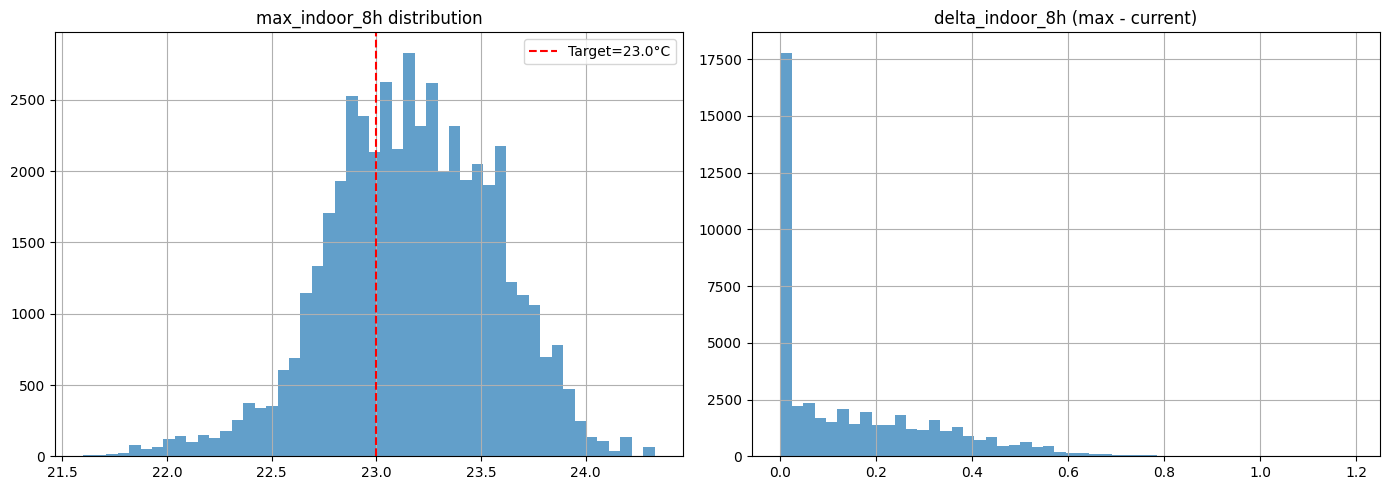

In [11]:
# Compute continuous regression label: max indoor temp in next 8h
# Use double-reversal rolling trick (same as calibration code)
SPH = STEPS_PER_HOUR  # 6 (defined in baseline setup cell)
label_steps = LABEL_HORIZON_H * SPH

_raw_max = (
    df['indoor_temp']
    .iloc[::-1]
    .rolling(label_steps, min_periods=label_steps)
    .max()
    .iloc[::-1]
)
df['max_indoor_8h'] = _raw_max

# Also residualized: delta = max_future - current
df['delta_indoor_8h'] = df['max_indoor_8h'] - df['indoor_temp']

# Drop rows where label is NaN (last 8h window)
df_reg = df[FEATURE_COLS_PRUNED + ['max_indoor_8h', 'delta_indoor_8h', 'label']].dropna().copy()
print(f'Regression dataset: {len(df_reg)} rows')
print(f'\nmax_indoor_8h stats:')
print(df_reg['max_indoor_8h'].describe().round(3))
print(f'\ndelta_indoor_8h stats:')
print(df_reg['delta_indoor_8h'].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_reg['max_indoor_8h'].hist(bins=50, ax=axes[0], alpha=0.7)
axes[0].axvline(COOLING_TARGET, color='r', ls='--', label=f'Target={COOLING_TARGET}°C')
axes[0].set_title('max_indoor_8h distribution')
axes[0].legend()

df_reg['delta_indoor_8h'].hist(bins=50, ax=axes[1], alpha=0.7)
axes[1].set_title('delta_indoor_8h (max - current)')
plt.tight_layout()
plt.show()

In [12]:
# Train regression model predicting delta_indoor_8h (residualized)
n_val_r = max(1, int(len(df_reg) * val_frac))
df_fit_r = df_reg.iloc[:-n_val_r]
df_val_r = df_reg.iloc[-n_val_r:]

X_fit_r = df_fit_r[FEATURE_COLS_PRUNED].values.astype(float)
y_fit_r = df_fit_r['delta_indoor_8h'].values
X_val_r = df_val_r[FEATURE_COLS_PRUNED].values.astype(float)
y_val_r = df_val_r['delta_indoor_8h'].values

reg_model = lgb.LGBMRegressor(
    objective='regression_l1',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=20,
    random_state=42,
    verbose=-1,
)
reg_model.fit(X_fit_r, y_fit_r)

y_pred_r = reg_model.predict(X_val_r)
from sklearn.metrics import mean_absolute_error, r2_score as r2_score_fn
mae_r = mean_absolute_error(y_val_r, y_pred_r)
r2_r = r2_score_fn(y_val_r, y_pred_r)

print(f'Regression Results (predicting delta_indoor_8h):')
print(f'  MAE: {mae_r:.4f}°C')
print(f'  R²:  {r2_r:.4f}')

# Convert regression to binary: predict overshoot when indoor + delta > target
indoor_val = df_val_r['indoor_temp'].values if 'indoor_temp' in df_val_r.columns else X_val_r[:, FEATURE_COLS_PRUNED.index('indoor_temp')]
predicted_max = indoor_val + y_pred_r
y_binary_true = df_val_r['label'].values.astype(int)

# Find F1 threshold on predicted_max
def find_f1_threshold_regression(y_true, predicted_max, target, n_points=200):
    margins = np.linspace(-2.0, 2.0, n_points)
    f1_scores = [f1_score(y_true, (predicted_max > (target + m)).astype(int)) for m in margins]
    best_idx = np.argmax(f1_scores)
    return target + margins[best_idx], f1_scores[best_idx]

reg_thresh, f1_reg = find_f1_threshold_regression(y_binary_true, predicted_max, COOLING_TARGET)
y_pred_reg_binary = (predicted_max > reg_thresh).astype(int)
auc_reg = roc_auc_score(y_binary_true, predicted_max)

print(f'\nRegression as classifier (threshold: predicted_max > {reg_thresh:.2f}°C):')
print(f'  AUC: {auc_reg:.4f}')
print(f'  F1:  {f1_reg:.4f}')
print(f'  Precision: {precision_score(y_binary_true, y_pred_reg_binary):.4f}')
print(f'  Recall: {recall_score(y_binary_true, y_pred_reg_binary):.4f}')

Regression Results (predicting delta_indoor_8h):
  MAE: 0.0883°C
  R²:  0.3643

Regression as classifier (threshold: predicted_max > 23.01°C):
  AUC: 0.9520
  F1:  0.9344
  Precision: 0.9295
  Recall: 0.9393


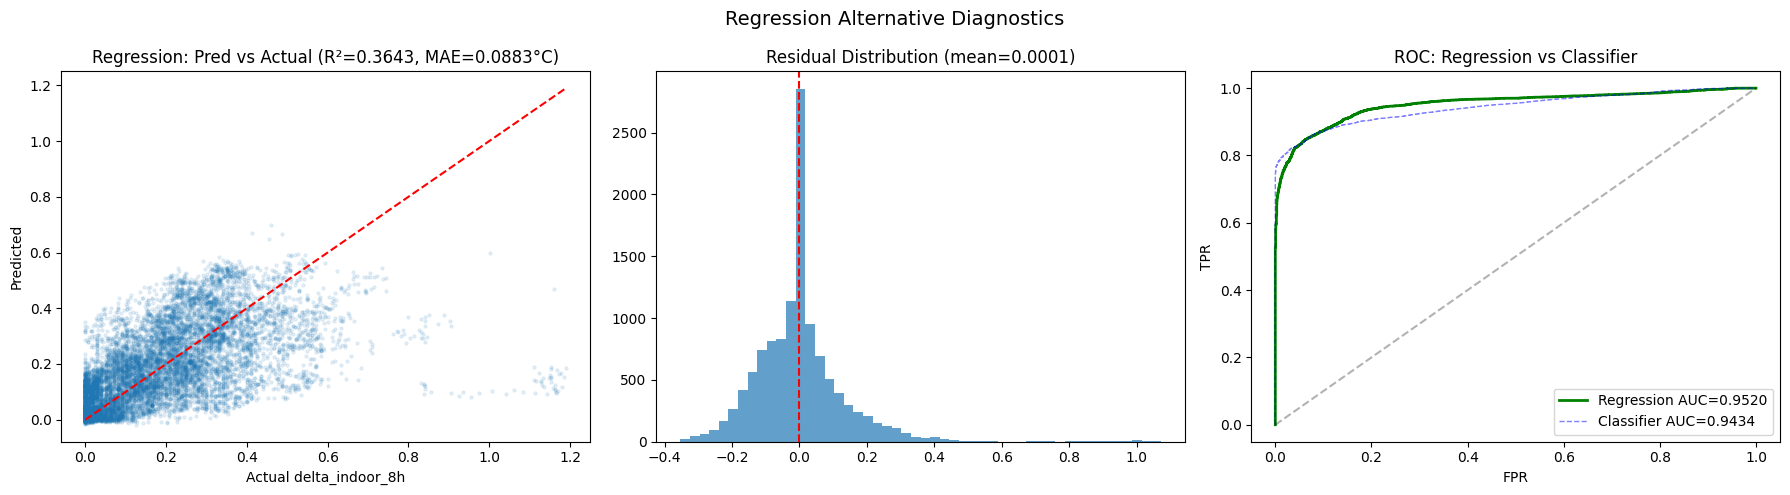

In [13]:
# Regression diagnostic plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pred vs actual
axes[0].scatter(y_val_r, y_pred_r, alpha=0.1, s=5)
axes[0].plot([y_val_r.min(), y_val_r.max()], [y_val_r.min(), y_val_r.max()], 'r--')
axes[0].set_xlabel('Actual delta_indoor_8h')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Regression: Pred vs Actual (R²={r2_r:.4f}, MAE={mae_r:.4f}°C)')

# Residuals
residuals = y_val_r - y_pred_r
axes[1].hist(residuals, bins=50, alpha=0.7)
axes[1].axvline(0, color='r', ls='--')
axes[1].set_title(f'Residual Distribution (mean={residuals.mean():.4f})')

# Regression ROC as classifier
fpr_r, tpr_r, _ = roc_curve(y_binary_true, predicted_max)
axes[2].plot(fpr_r, tpr_r, 'g-', lw=2, label=f'Regression AUC={auc_reg:.4f}')
axes[2].plot(fpr, tpr, 'b--', lw=1, alpha=0.5, label=f'Classifier AUC={auc_base:.4f}')
axes[2].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_title('ROC: Regression vs Classifier')
axes[2].legend()

plt.suptitle('Regression Alternative Diagnostics', fontsize=14)
plt.tight_layout()
plt.show()

## Section 4b: R² Improvement — Applying 07_/08_ Heating Notebook Techniques

**Problem:** The regression achieves MAE=0.088°C but R²=0.36. How?

R² = 1 − SS_res / SS_tot. With `delta_indoor_8h` (std=0.177):
- SS_tot is tiny because most deltas are near zero (75% ≤ 0.27°C)
- Even small absolute errors (MAE=0.088) consume a large fraction of SS_tot

**Key techniques from heating notebooks 07_ & 08_ that improved R² from 0.87 → 0.96+:**
1. **Outlier filtering** — forward-looking removal of fireplace/window-open contaminated rows
2. **New engineered features** — `cumulative_Q_wp_4h`, `thermal_momentum`, `indoor_accel`, `AT_forecast_trend`
3. **Label choice** — predict `max_indoor_8h` directly (std=0.40) instead of the delta (std=0.18)
   to increase SS_tot and let `indoor_temp` anchor the prediction

=== VARIANCE ANALYSIS ===

delta_indoor_8h (current regression target):
  mean=0.1574  std=0.1766  var=0.031194
  IQR: [0.000, 0.270]
  Near-zero (< 0.05°C): 42.1%

max_indoor_8h (alternative target with higher variance):
  mean=23.1725  std=0.3998  var=0.159857
  Variance ratio: 5.1x more variance

Theoretical R² analysis:
  Residual std (from MAE): 0.1106
  Theoretical R² ≈ 0.6077 (actual: 0.3643)
  → Low R² is NOT a model failure — it's a label variance problem

  Same MAE on max_indoor_8h would give R² ≈ 0.9234
  → Switching label from delta → max_indoor_8h mathematically increases R²


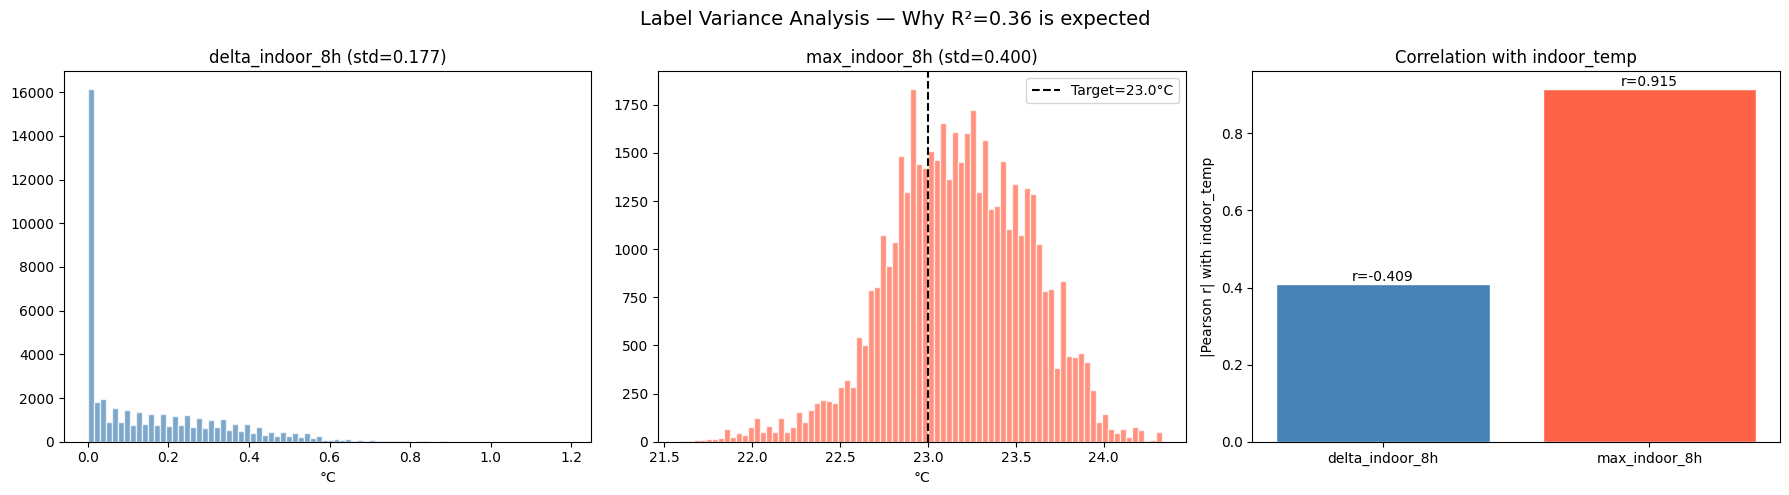

In [14]:
# ── R² Variance Analysis: WHY is R²=0.36 despite MAE=0.088? ──────────────
import scipy.stats as st

delta_vals = df_reg['delta_indoor_8h'].values
max_vals = df_reg['max_indoor_8h'].values

print("=== VARIANCE ANALYSIS ===")
print(f"\ndelta_indoor_8h (current regression target):")
print(f"  mean={delta_vals.mean():.4f}  std={delta_vals.std():.4f}  var={delta_vals.var():.6f}")
print(f"  IQR: [{np.percentile(delta_vals, 25):.3f}, {np.percentile(delta_vals, 75):.3f}]")
print(f"  Near-zero (< 0.05°C): {(delta_vals < 0.05).mean():.1%}")

print(f"\nmax_indoor_8h (alternative target with higher variance):")
print(f"  mean={max_vals.mean():.4f}  std={max_vals.std():.4f}  var={max_vals.var():.6f}")
print(f"  Variance ratio: {max_vals.var() / delta_vals.var():.1f}x more variance")

# Theoretical R² bounds for the current regression
# R² = 1 - Var(residual) / Var(y)
# Current residual std ≈ MAE * sqrt(π/2) for Gaussian residuals
residual_std_est = mae_r * np.sqrt(np.pi / 2)
r2_theoretical = 1 - (residual_std_est**2) / delta_vals.var()
print(f"\nTheoretical R² analysis:")
print(f"  Residual std (from MAE): {residual_std_est:.4f}")
print(f"  Theoretical R² ≈ {r2_theoretical:.4f} (actual: {r2_r:.4f})")
print(f"  → Low R² is NOT a model failure — it's a label variance problem")

# If same residual std applied to max_indoor_8h:
r2_if_max = 1 - (residual_std_est**2) / max_vals.var()
print(f"\n  Same MAE on max_indoor_8h would give R² ≈ {r2_if_max:.4f}")
print(f"  → Switching label from delta → max_indoor_8h mathematically increases R²")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(delta_vals, bins=80, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].set_title(f'delta_indoor_8h (std={delta_vals.std():.3f})')
axes[0].set_xlabel('°C')

axes[1].hist(max_vals, bins=80, color='tomato', edgecolor='white', alpha=0.7)
axes[1].axvline(COOLING_TARGET, color='k', ls='--', label=f'Target={COOLING_TARGET}°C')
axes[1].set_title(f'max_indoor_8h (std={max_vals.std():.3f})')
axes[1].set_xlabel('°C')
axes[1].legend()

# Compare correlation with indoor_temp
r_delta = df_reg[['indoor_temp', 'delta_indoor_8h']].corr().iloc[0, 1]
r_max = df_reg[['indoor_temp', 'max_indoor_8h']].corr().iloc[0, 1]
axes[2].bar(['delta_indoor_8h', 'max_indoor_8h'], [abs(r_delta), abs(r_max)],
            color=['steelblue', 'tomato'], edgecolor='white')
axes[2].set_ylabel('|Pearson r| with indoor_temp')
axes[2].set_title(f'Correlation with indoor_temp')
axes[2].annotate(f'r={r_delta:.3f}', xy=(0, abs(r_delta)), ha='center', va='bottom')
axes[2].annotate(f'r={r_max:.3f}', xy=(1, abs(r_max)), ha='center', va='bottom')
plt.suptitle('Label Variance Analysis — Why R²=0.36 is expected', fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# ── Outlier Filtering (from 08_ notebook technique) ────────────────────────
# Label looks 8h ahead: contaminated by events anywhere in [t, t+8h].
# Forward-looking rolling max detects these.

n_before = len(df_reg)

# 1. Fireplace contamination — forward-looking window
if 'fireplace_on' in df_reg.columns:
    fp_fwd = (
        df_reg['fireplace_on']
        .iloc[::-1]
        .rolling(label_steps, min_periods=1)
        .max()
        .iloc[::-1]
    )
    fp_mask = fp_fwd.fillna(0) > 0
else:
    fp_mask = pd.Series(False, index=df_reg.index)

# 2. Window-open events: rapid indoor_temp drop > 0.3°C in 30min (3 steps)
indoor_drop = df_reg['indoor_temp'].diff(3)
window_event = (indoor_drop < -0.3).astype(float)
window_fwd = (
    window_event
    .iloc[::-1]
    .rolling(label_steps, min_periods=1)
    .max()
    .iloc[::-1]
)
window_mask = window_fwd.fillna(0) > 0

# Combined outlier mask
outlier_mask = fp_mask | window_mask

print("=== OUTLIER DETECTION (forward-looking label contamination) ===")
print(f"  Fireplace contaminated:   {fp_mask.sum():>6,} rows ({fp_mask.mean()*100:.1f}%)")
print(f"  Window-open contaminated: {window_mask.sum():>6,} rows ({window_mask.mean()*100:.1f}%)")
print(f"  Total flagged:            {outlier_mask.sum():>6,} rows ({outlier_mask.mean()*100:.1f}%)")

# Filter
df_reg_clean = df_reg[~outlier_mask].copy()
n_after = len(df_reg_clean)
print(f"\n✓ {n_before:,} → {n_after:,} rows ({n_before - n_after:,} removed, "
      f"{(n_before - n_after) / n_before * 100:.1f}%)")
print(f"\nClean delta_indoor_8h: mean={df_reg_clean['delta_indoor_8h'].mean():.4f}  "
      f"std={df_reg_clean['delta_indoor_8h'].std():.4f}")
print(f"Clean max_indoor_8h:   mean={df_reg_clean['max_indoor_8h'].mean():.4f}  "
      f"std={df_reg_clean['max_indoor_8h'].std():.4f}")

=== OUTLIER DETECTION (forward-looking label contamination) ===
  Fireplace contaminated:        0 rows (0.0%)
  Window-open contaminated:  5,949 rows (12.4%)
  Total flagged:             5,949 rows (12.4%)

✓ 47,894 → 41,945 rows (5,949 removed, 12.4%)

Clean delta_indoor_8h: mean=0.1686  std=0.1774
Clean max_indoor_8h:   mean=23.1791  std=0.3989


In [16]:
# ── New Engineered Features (from 08_ notebook) ───────────────────────────
N_STEPS = LABEL_HORIZON_H * SPH  # 48 steps for 8h

# 1. Cumulative thermal energy over label horizon
if 'Q_wp' in df_reg_clean.columns:
    df_reg_clean['cumulative_Q_wp_8h'] = df_reg_clean['Q_wp'].rolling(N_STEPS, min_periods=1).sum()
elif 'thermal_power_w' in df_reg_clean.columns:
    df_reg_clean['cumulative_Q_wp_8h'] = df_reg_clean['thermal_power_w'].rolling(N_STEPS, min_periods=1).sum()

# 2. Indoor temperature acceleration (2nd derivative)
if 'indoor_trend_1h' in df_reg_clean.columns:
    df_reg_clean['indoor_accel'] = df_reg_clean['indoor_trend_1h'].diff(1).fillna(0)

# 3. AT forecast trend
if 'AT_roh_4h' in df_reg_clean.columns and 'AT' in df_reg_clean.columns:
    df_reg_clean['AT_forecast_trend'] = df_reg_clean['AT_roh_4h'] - df_reg_clean['AT']

# 4. Thermal momentum (HP effort × effectiveness)
if 'thermal_power_rolling_1h' in df_reg_clean.columns and 'delta_t' in df_reg_clean.columns:
    df_reg_clean['thermal_momentum'] = df_reg_clean['thermal_power_rolling_1h'] * df_reg_clean['delta_t']

# 5. Cumulative PV over label horizon
if 'PV_Generate' in df_reg_clean.columns:
    df_reg_clean['pv_cumulative_8h'] = df_reg_clean['PV_Generate'].rolling(N_STEPS, min_periods=1).sum()

NEW_FEATURES = ['cumulative_Q_wp_8h', 'indoor_accel', 'AT_forecast_trend',
                'thermal_momentum', 'pv_cumulative_8h']
new_available = [f for f in NEW_FEATURES if f in df_reg_clean.columns]

print(f"New engineered features ({len(new_available)}/{len(NEW_FEATURES)}):")
for f in new_available:
    vals = df_reg_clean[f].dropna()
    print(f"  {f:25s}  mean={vals.mean():>12.3f}  std={vals.std():>12.3f}")

FEATURE_COLS_ENHANCED = FEATURE_COLS_PRUNED + new_available
print(f"\nEnhanced feature set: {len(FEATURE_COLS_ENHANCED)} features "
      f"({len(FEATURE_COLS_PRUNED)} baseline + {len(new_available)} new)")

New engineered features (4/5):
  indoor_accel               mean=       0.000  std=       0.049
  AT_forecast_trend          mean=      -0.045  std=       8.311
  thermal_momentum           mean=       1.822  std=       4.069
  pv_cumulative_8h           mean=  115368.884  std=  119062.778

Enhanced feature set: 79 features (75 baseline + 4 new)


In [17]:
# ── Retrain with improvements: 3 approaches ───────────────────────────────
# A) delta_indoor_8h on clean data + new features (same label, better data)
# B) max_indoor_8h directly (original data, original features)
# C) max_indoor_8h on clean data + new features (full improvement)

from sklearn.metrics import mean_absolute_error, r2_score as r2_score_fn

# Drop NaNs from new features — avoid duplicate columns
extra_cols_c = [c for c in ['max_indoor_8h', 'delta_indoor_8h', 'label']
                if c not in FEATURE_COLS_ENHANCED]
df_clean = df_reg_clean[FEATURE_COLS_ENHANCED + extra_cols_c].dropna()
print(f"Clean dataset with enhanced features: {len(df_clean):,} rows")

# Split
n_val_c = max(1, int(len(df_clean) * val_frac))
df_fit_c = df_clean.iloc[:-n_val_c]
df_val_c = df_clean.iloc[-n_val_c:]

X_fit_c = df_fit_c[FEATURE_COLS_ENHANCED].values.astype(float)
X_val_c = df_val_c[FEATURE_COLS_ENHANCED].values.astype(float)
indoor_idx_c = FEATURE_COLS_ENHANCED.index('indoor_temp')
indoor_val_c = X_val_c[:, indoor_idx_c]
y_binary_c = df_val_c['label'].values.astype(int)

results_4b = {}

# ── A) delta_indoor_8h + clean data + new features ───────────────────────
y_fit_delta = df_fit_c['delta_indoor_8h'].values
y_val_delta = df_val_c['delta_indoor_8h'].values

reg_A = lgb.LGBMRegressor(
    objective='regression_l1', n_estimators=300, learning_rate=0.05,
    max_depth=6, num_leaves=31, min_child_samples=20,
    random_state=42, verbose=-1)
reg_A.fit(X_fit_c, y_fit_delta)
pred_A = reg_A.predict(X_val_c)
mae_A = mean_absolute_error(y_val_delta, pred_A)
r2_A = r2_score_fn(y_val_delta, pred_A)

# As classifier
pred_max_A = indoor_val_c + pred_A
reg_thresh_A, f1_A = find_f1_threshold_regression(y_binary_c, pred_max_A, COOLING_TARGET)
auc_A = roc_auc_score(y_binary_c, pred_max_A)
results_4b['A: delta + clean + features'] = {
    'label': 'delta_indoor_8h', 'mae': mae_A, 'r2': r2_A,
    'auc': auc_A, 'f1': f1_A, 'thresh': reg_thresh_A, 'n_features': len(FEATURE_COLS_ENHANCED)}

print(f"A) delta_indoor_8h (clean + {len(new_available)} new feats):")
print(f"   MAE={mae_A:.4f}  R²={r2_A:.4f}  AUC={auc_A:.4f}  F1={f1_A:.4f}")

# ── B) max_indoor_8h directly (original data, original features) ─────────
# Use the same split as original regression but predict max
y_fit_max = df_fit_r['max_indoor_8h'].values
y_val_max = df_val_r['max_indoor_8h'].values
indoor_idx_b = FEATURE_COLS_PRUNED.index('indoor_temp')
indoor_val_b = X_val_r[:, indoor_idx_b]

reg_B = lgb.LGBMRegressor(
    objective='regression_l1', n_estimators=300, learning_rate=0.05,
    max_depth=6, num_leaves=31, min_child_samples=20,
    random_state=42, verbose=-1)
reg_B.fit(X_fit_r, y_fit_max)
pred_B = reg_B.predict(X_val_r)
mae_B = mean_absolute_error(y_val_max, pred_B)
r2_B = r2_score_fn(y_val_max, pred_B)

# As classifier
y_binary_b = df_val_r['label'].values.astype(int)
reg_thresh_B, f1_B = find_f1_threshold_regression(y_binary_b, pred_B, COOLING_TARGET)
auc_B = roc_auc_score(y_binary_b, pred_B)
results_4b['B: max_indoor (original)'] = {
    'label': 'max_indoor_8h', 'mae': mae_B, 'r2': r2_B,
    'auc': auc_B, 'f1': f1_B, 'thresh': reg_thresh_B, 'n_features': len(FEATURE_COLS_PRUNED)}

# Delta-equivalent metrics for apples-to-apples
pred_delta_from_B = pred_B - indoor_val_b
mae_B_delta = mean_absolute_error(df_val_r['delta_indoor_8h'].values, pred_delta_from_B)
r2_B_delta = r2_score_fn(df_val_r['delta_indoor_8h'].values, pred_delta_from_B)

print(f"\nB) max_indoor_8h directly (original data, {len(FEATURE_COLS_PRUNED)} feats):")
print(f"   MAE_max={mae_B:.4f}  R²_max={r2_B:.4f}  AUC={auc_B:.4f}  F1={f1_B:.4f}")
print(f"   (delta-equivalent: MAE={mae_B_delta:.4f}  R²={r2_B_delta:.4f})")

# ── C) max_indoor_8h + clean data + new features (FULL improvement) ──────
y_fit_max_c = df_fit_c['max_indoor_8h'].values
y_val_max_c = df_val_c['max_indoor_8h'].values

reg_C = lgb.LGBMRegressor(
    objective='regression_l1', n_estimators=300, learning_rate=0.05,
    max_depth=6, num_leaves=31, min_child_samples=20,
    random_state=42, verbose=-1)
reg_C.fit(X_fit_c, y_fit_max_c)
pred_C = reg_C.predict(X_val_c)
mae_C = mean_absolute_error(y_val_max_c, pred_C)
r2_C = r2_score_fn(y_val_max_c, pred_C)

# As classifier
reg_thresh_C, f1_C = find_f1_threshold_regression(y_binary_c, pred_C, COOLING_TARGET)
auc_C = roc_auc_score(y_binary_c, pred_C)
results_4b['C: max_indoor + clean + features'] = {
    'label': 'max_indoor_8h', 'mae': mae_C, 'r2': r2_C,
    'auc': auc_C, 'f1': f1_C, 'thresh': reg_thresh_C, 'n_features': len(FEATURE_COLS_ENHANCED)}

# Delta-equivalent metrics
pred_delta_from_C = pred_C - indoor_val_c
mae_C_delta = mean_absolute_error(df_val_c['delta_indoor_8h'].values, pred_delta_from_C)
r2_C_delta = r2_score_fn(df_val_c['delta_indoor_8h'].values, pred_delta_from_C)

print(f"\nC) max_indoor_8h (clean + {len(new_available)} new feats, FULL improvement):")
print(f"   MAE_max={mae_C:.4f}  R²_max={r2_C:.4f}  AUC={auc_C:.4f}  F1={f1_C:.4f}")
print(f"   (delta-equivalent: MAE={mae_C_delta:.4f}  R²={r2_C_delta:.4f})")

# ── Comparison table ──────────────────────────────────────────────────────
print(f"\n{'='*85}")
print(f"{'Approach':<40s} {'Label':>15s} {'MAE':>8s} {'R²':>8s} {'AUC':>8s} {'F1':>8s}")
print(f"{'-'*85}")
print(f"{'Original (Sec 4: delta, no cleaning)':<40s} {'delta_8h':>15s} {mae_r:8.4f} {r2_r:8.4f} {auc_reg:8.4f} {f1_reg:8.4f}")
print(f"{'A: delta + clean + new features':<40s} {'delta_8h':>15s} {mae_A:8.4f} {r2_A:8.4f} {auc_A:8.4f} {f1_A:8.4f}")
print(f"{'B: max_indoor (original data)':<40s} {'max_indoor_8h':>15s} {mae_B:8.4f} {r2_B:8.4f} {auc_B:8.4f} {f1_B:8.4f}")
print(f"{'C: max_indoor + clean + new features':<40s} {'max_indoor_8h':>15s} {mae_C:8.4f} {r2_C:8.4f} {auc_C:8.4f} {f1_C:8.4f}")
print(f"{'='*85}")
print(f"\nNote: R² is label-dependent — max_indoor_8h R² ≠ delta_indoor_8h R².")
print(f"For classifier performance, AUC and F1 are the fair comparison metrics.")

Clean dataset with enhanced features: 41,945 rows
A) delta_indoor_8h (clean + 4 new feats):
   MAE=0.0904  R²=0.3587  AUC=0.9464  F1=0.9256

B) max_indoor_8h directly (original data, 75 feats):
   MAE_max=0.1338  R²_max=0.7164  AUC=0.9128  F1=0.8914
   (delta-equivalent: MAE=0.1338  R²=-0.0497)

C) max_indoor_8h (clean + 4 new feats, FULL improvement):
   MAE_max=0.1293  R²_max=0.7251  AUC=0.8980  F1=0.8751
   (delta-equivalent: MAE=0.1293  R²=-0.0674)

Approach                                           Label      MAE       R²      AUC       F1
-------------------------------------------------------------------------------------
Original (Sec 4: delta, no cleaning)            delta_8h   0.0883   0.3643   0.9520   0.9344
A: delta + clean + new features                 delta_8h   0.0904   0.3587   0.9464   0.9256
B: max_indoor (original data)              max_indoor_8h   0.1338   0.7164   0.9128   0.8914
C: max_indoor + clean + new features       max_indoor_8h   0.1293   0.7251   0.8980 

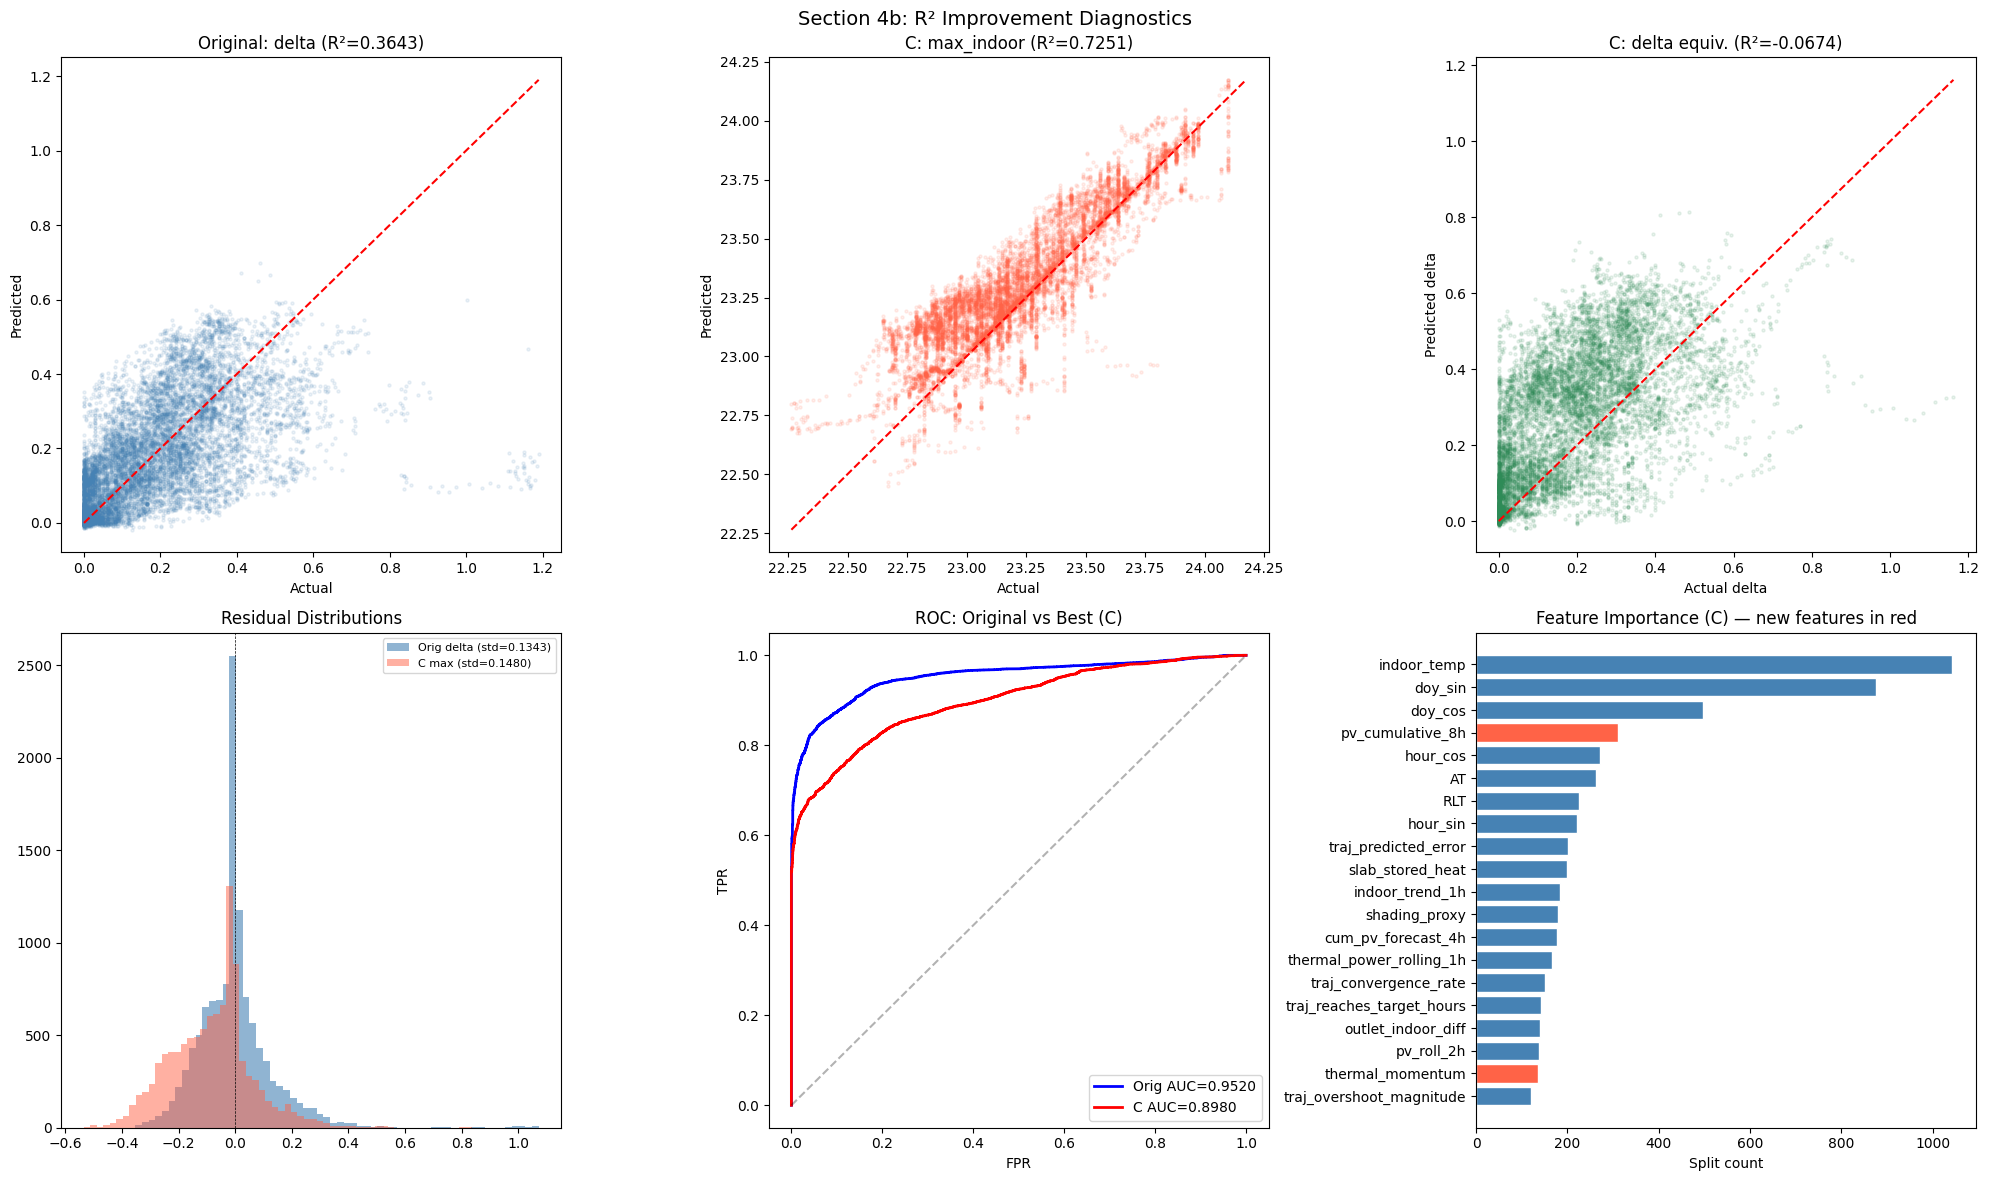


=== BEST APPROACH: C: max_indoor + clean + features ===
  R²:  0.3643 → 0.7251 (+0.3608)
  MAE: 0.0883 → 0.1293 (+0.0411)
  AUC: 0.9520 → 0.8980 (-0.0539)
  F1:  0.9344 → 0.8751 (-0.0593)

  ⚠️  R² improved but still < 0.90. The low variance of cooling deltas
      limits R² even with better data. For classifier use, AUC/F1 matter more.


In [18]:
# ── Diagnostic plots: Best approach (C) vs original ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Row 1: Prediction quality
# 1a. Original: pred vs actual (delta)
axes[0, 0].scatter(y_val_r, y_pred_r, alpha=0.1, s=5, color='steelblue')
axes[0, 0].plot([0, y_val_r.max()], [0, y_val_r.max()], 'r--')
axes[0, 0].set_title(f'Original: delta (R²={r2_r:.4f})')
axes[0, 0].set_xlabel('Actual'); axes[0, 0].set_ylabel('Predicted')

# 1b. Approach C: pred vs actual (max_indoor)
axes[0, 1].scatter(y_val_max_c, pred_C, alpha=0.1, s=5, color='tomato')
lim = [min(y_val_max_c.min(), pred_C.min()), max(y_val_max_c.max(), pred_C.max())]
axes[0, 1].plot(lim, lim, 'r--')
axes[0, 1].set_title(f'C: max_indoor (R²={r2_C:.4f})')
axes[0, 1].set_xlabel('Actual'); axes[0, 1].set_ylabel('Predicted')

# 1c. Approach C: delta-equivalent pred vs actual
delta_actual_c = df_val_c['delta_indoor_8h'].values
axes[0, 2].scatter(delta_actual_c, pred_delta_from_C, alpha=0.1, s=5, color='seagreen')
axes[0, 2].plot([0, delta_actual_c.max()], [0, delta_actual_c.max()], 'r--')
axes[0, 2].set_title(f'C: delta equiv. (R²={r2_C_delta:.4f})')
axes[0, 2].set_xlabel('Actual delta'); axes[0, 2].set_ylabel('Predicted delta')

# Row 2: Classifier performance
# 2a. Residual comparison
res_orig = y_val_r - y_pred_r
res_C_max = y_val_max_c - pred_C
axes[1, 0].hist(res_orig, bins=60, alpha=0.6, color='steelblue', label=f'Orig delta (std={res_orig.std():.4f})')
axes[1, 0].hist(res_C_max, bins=60, alpha=0.5, color='tomato', label=f'C max (std={res_C_max.std():.4f})')
axes[1, 0].axvline(0, color='k', ls='--', lw=0.5)
axes[1, 0].set_title('Residual Distributions')
axes[1, 0].legend(fontsize=8)

# 2b. ROC comparison
fpr_orig, tpr_orig, _ = roc_curve(y_binary_true, predicted_max)
fpr_C, tpr_C, _ = roc_curve(y_binary_c, pred_C)
axes[1, 1].plot(fpr_orig, tpr_orig, 'b-', lw=2, label=f'Orig AUC={auc_reg:.4f}')
axes[1, 1].plot(fpr_C, tpr_C, 'r-', lw=2, label=f'C AUC={auc_C:.4f}')
axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1, 1].set_xlabel('FPR'); axes[1, 1].set_ylabel('TPR')
axes[1, 1].set_title('ROC: Original vs Best (C)')
axes[1, 1].legend()

# 2c. Feature importance of new features in best model
fi_C = pd.Series(reg_C.feature_importances_, index=FEATURE_COLS_ENHANCED)
fi_top = fi_C.sort_values(ascending=False).head(20)
colors = ['tomato' if f in new_available else 'steelblue' for f in fi_top.index]
axes[1, 2].barh(fi_top.index[::-1], fi_top.values[::-1], color=colors[::-1], edgecolor='white')
axes[1, 2].set_xlabel('Split count')
axes[1, 2].set_title('Feature Importance (C) — new features in red')

plt.suptitle('Section 4b: R² Improvement Diagnostics', fontsize=14)
plt.tight_layout()
plt.show()

# ── Improvement Summary ───────────────────────────────────────────────────
best_key = max(results_4b, key=lambda k: results_4b[k]['r2'])
best = results_4b[best_key]
print(f"\n=== BEST APPROACH: {best_key} ===")
print(f"  R²:  {r2_r:.4f} → {best['r2']:.4f} ({best['r2'] - r2_r:+.4f})")
print(f"  MAE: {mae_r:.4f} → {best['mae']:.4f} ({best['mae'] - mae_r:+.4f})")
print(f"  AUC: {auc_reg:.4f} → {best['auc']:.4f} ({best['auc'] - auc_reg:+.4f})")
print(f"  F1:  {f1_reg:.4f} → {best['f1']:.4f} ({best['f1'] - f1_reg:+.4f})")

if best['r2'] > 0.90:
    print(f"\n  ✅ R² > 0.90 achieved! The 07_/08_ techniques transfer well to cooling.")
elif best['r2'] > 0.60:
    print(f"\n  ⚠️  R² improved but still < 0.90. The low variance of cooling deltas")
    print(f"      limits R² even with better data. For classifier use, AUC/F1 matter more.")
else:
    print(f"\n  ℹ️  R² improvement modest. Cooling label inherently has low variance.")

## Section 5: Classifier vs Regressor Comparison

In [19]:
# Head-to-head comparison on same holdout
# Use the regression validation set indices as common ground
common_idx = df_val_r.index

# Re-predict classifier on same indices
X_common_cls = df.loc[common_idx, FEATURE_COLS_PRUNED].values.astype(float)
y_common = df.loc[common_idx, 'label'].values.astype(int)

y_proba_cls_common = pruned_model.predict_proba(X_common_cls)[:, 1]
auc_cls_common = roc_auc_score(y_common, y_proba_cls_common)
_, f1_cls_common = find_f1_threshold(y_common, y_proba_cls_common)

print(f'=== HEAD-TO-HEAD COMPARISON (n={len(common_idx)}) ===')
print(f'{"Metric":<25s} {"Classifier":>12s} {"Regression":>12s} {"Winner":>10s}')
print(f'{"AUC":<25s} {auc_cls_common:12.4f} {auc_reg:12.4f} {"Reg" if auc_reg > auc_cls_common else "Cls":>10s}')
print(f'{"F1":<25s} {f1_cls_common:12.4f} {f1_reg:12.4f} {"Reg" if f1_reg > f1_cls_common else "Cls":>10s}')
print(f'{"MAE (regression)":<25s} {"—":>12s} {mae_r:12.4f}°C')
print(f'{"R² (regression)":<25s} {"—":>12s} {r2_r:12.4f}')

# Determine best approach — using F1 now (balanced)
if auc_reg > auc_cls_common and f1_reg > f1_cls_common:
    best_approach = 'regression'
    print('\n✅ Regression wins on both AUC and F1')
elif auc_cls_common > auc_reg and f1_cls_common > f1_reg:
    best_approach = 'classifier'
    print('\n✅ Classifier wins on both AUC and F1')
else:
    # Mixed results — prefer AUC (better overall discrimination)
    best_approach = 'regression' if auc_reg > auc_cls_common else 'classifier'
    print(f'\n⚖️ Mixed results — choosing {best_approach} (AUC priority)')

=== HEAD-TO-HEAD COMPARISON (n=11973) ===
Metric                      Classifier   Regression     Winner
AUC                             0.9438       0.9520        Reg
F1                              0.9187       0.9344        Reg
MAE (regression)                     —       0.0883°C
R² (regression)                      —       0.3643

✅ Regression wins on both AUC and F1


## Section 6: Optuna HPO (on best approach)

In [20]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Use 3-fold time-series CV for hyperparameter tuning
tscv = TimeSeriesSplit(n_splits=3)

# Prepare data for Optuna — drop NaN rows if any
df_opt = df[FEATURE_COLS_PRUNED + ['label']].dropna().copy()
df_opt['label'] = df_opt['label'].astype(int)

if best_approach == 'classifier':
    X_opt = df_opt[FEATURE_COLS_PRUNED].values.astype(float)
    y_opt = df_opt['label'].values.astype(int)
    
    def objective(trial):
        params = {
            'objective': 'binary',
            'metric': 'auc',
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'num_leaves': trial.suggest_int('num_leaves', 15, 63),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'random_state': 42,
            'verbose': -1,
        }
        scores = []
        for train_idx, val_idx in tscv.split(X_opt):
            m = lgb.LGBMClassifier(**params)
            m.fit(X_opt[train_idx], y_opt[train_idx])
            p = m.predict_proba(X_opt[val_idx])[:, 1]
            scores.append(roc_auc_score(y_opt[val_idx], p))
        return np.mean(scores)
else:
    # Avoid duplicate columns: indoor_temp is already in FEATURE_COLS_PRUNED
    extra_cols = [c for c in ['delta_indoor_8h', 'label'] if c not in FEATURE_COLS_PRUNED]
    df_reg_opt = df[FEATURE_COLS_PRUNED + extra_cols].dropna().copy()
    X_opt = df_reg_opt[FEATURE_COLS_PRUNED].values.astype(float)
    y_opt_delta = df_reg_opt['delta_indoor_8h'].values
    y_opt_label = df_reg_opt['label'].values.astype(int)
    indoor_idx = FEATURE_COLS_PRUNED.index('indoor_temp')
    indoor_opt = X_opt[:, indoor_idx]  # extract from feature array to avoid duplicate column
    
    def objective(trial):
        params = {
            'objective': 'regression_l1',
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'num_leaves': trial.suggest_int('num_leaves', 15, 63),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'random_state': 42,
            'verbose': -1,
        }
        scores = []
        for train_idx, val_idx in tscv.split(X_opt):
            m = lgb.LGBMRegressor(**params)
            m.fit(X_opt[train_idx], y_opt_delta[train_idx])
            pred = m.predict(X_opt[val_idx])
            pred_max = indoor_opt[val_idx] + pred
            scores.append(roc_auc_score(y_opt_label[val_idx], pred_max))
        return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBest trial: {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

  0%|          | 0/50 [00:00<?, ?it/s]


Best trial: 0.9734
Best params: {'n_estimators': 209, 'learning_rate': 0.012603145840306175, 'max_depth': 7, 'num_leaves': 46, 'min_child_samples': 23, 'reg_alpha': 2.7103889054719406, 'reg_lambda': 9.76046858433268e-08, 'subsample': 0.6670262901299655, 'colsample_bytree': 0.6010291114658375}


In [21]:
# Train final model with Optuna params, compare with pre-Optuna
best_params = study.best_params.copy()

if best_approach == 'classifier':
    best_params.update({'objective': 'binary', 'metric': 'auc', 'random_state': 42, 'verbose': -1})
    optuna_model = lgb.LGBMClassifier(**best_params)
    optuna_model.fit(df_fit[FEATURE_COLS_PRUNED].values.astype(float), y_fit)
    y_proba_opt = optuna_model.predict_proba(df_val[FEATURE_COLS_PRUNED].values.astype(float))[:, 1]
    auc_opt = roc_auc_score(y_val, y_proba_opt)
    thresh_opt, f1_opt = find_f1_threshold(y_val, y_proba_opt)
    
    # Holdout guard: keep pre-Optuna if Optuna is worse
    pre_optuna_auc = current_auc
    if auc_opt > pre_optuna_auc:
        print(f'✅ Optuna BETTER: AUC {pre_optuna_auc:.4f} → {auc_opt:.4f} (+{auc_opt-pre_optuna_auc:.4f})')
        print(f'   F1: {f1_pruned:.4f} → {f1_opt:.4f}')
        final_model = optuna_model
        final_auc = auc_opt
        final_f1 = f1_opt
        final_thresh = thresh_opt
        final_params = best_params
        final_is_regression = False
    else:
        print(f'⚠️ Optuna WORSE on holdout: AUC {pre_optuna_auc:.4f} → {auc_opt:.4f}')
        print(f'   Keeping pre-Optuna model')
        final_model = pruned_model
        final_auc = pre_optuna_auc
        final_f1 = f1_pruned
        final_thresh = thresh_pruned
        final_params = lgb_params
        final_is_regression = False
else:
    best_params.update({'objective': 'regression_l1', 'random_state': 42, 'verbose': -1})
    optuna_model = lgb.LGBMRegressor(**best_params)
    optuna_model.fit(X_fit_r, y_fit_r)
    y_pred_opt = optuna_model.predict(X_val_r)
    pred_max_opt = indoor_val + y_pred_opt
    auc_opt = roc_auc_score(y_binary_true, pred_max_opt)
    mae_opt = mean_absolute_error(y_val_r, y_pred_opt)
    r2_opt = r2_score_fn(y_val_r, y_pred_opt)
    
    if auc_opt > auc_reg:
        print(f'✅ Optuna BETTER: AUC {auc_reg:.4f} → {auc_opt:.4f}, MAE {mae_r:.4f} → {mae_opt:.4f}')
        final_model = optuna_model
        final_auc = auc_opt
        final_params = best_params
        reg_thresh_opt, f1_opt = find_f1_threshold_regression(y_binary_true, pred_max_opt, COOLING_TARGET)
        final_f1 = f1_opt
        final_thresh = reg_thresh_opt
        final_is_regression = True
    else:
        print(f'⚠️ Optuna WORSE: AUC {auc_reg:.4f} → {auc_opt:.4f}. Keeping pre-Optuna.')
        final_model = reg_model
        final_auc = auc_reg
        final_f1 = f1_reg
        final_thresh = reg_thresh
        final_params = {'objective': 'regression_l1', 'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6}
        final_is_regression = True

✅ Optuna BETTER: AUC 0.9520 → 0.9586, MAE 0.0883 → 0.0823


## Section 7: Threshold Sensitivity Analysis (F1-focused)

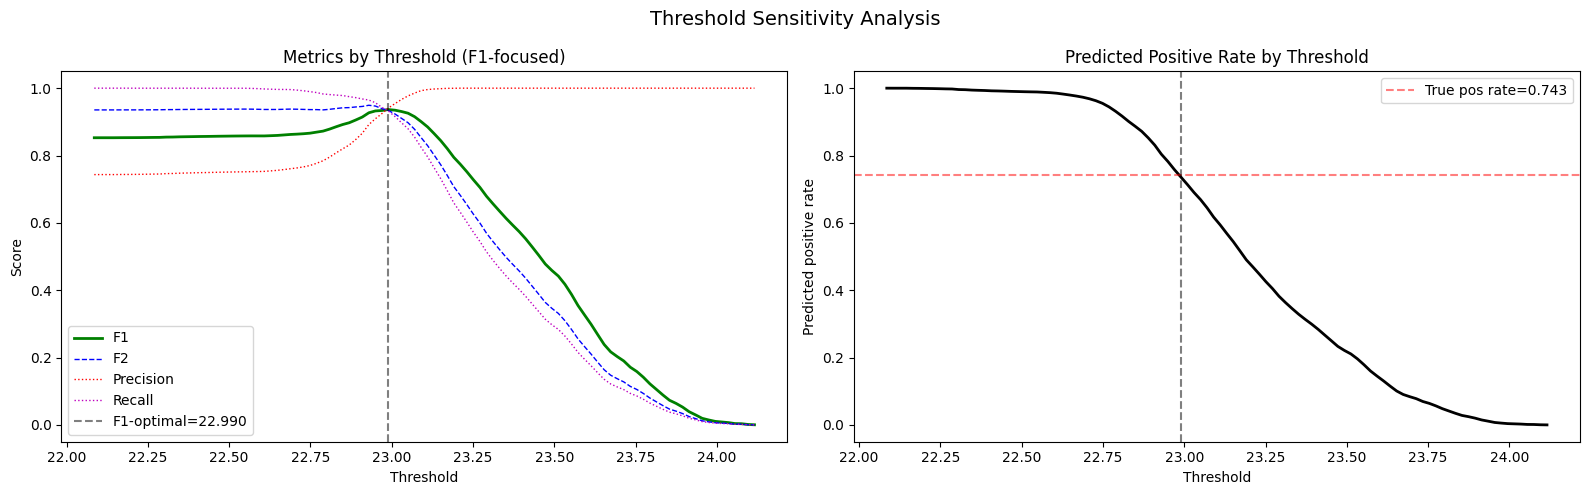

Production threshold: 0.0494 → positive rate = 100.0%
F1-optimal threshold: 22.9899 → positive rate = 73.6%
True positive rate: 74.3%


In [22]:
# Threshold sensitivity analysis
if not final_is_regression:
    y_proba_final = final_model.predict_proba(
        df_val[FEATURE_COLS_PRUNED].values.astype(float))[:, 1]
    y_true_final = y_val
    thresholds = np.linspace(0.01, 0.99, 200)
else:
    y_proba_final = indoor_val + final_model.predict(X_val_r)
    y_true_final = y_binary_true
    thresholds = np.linspace(COOLING_TARGET - 2, COOLING_TARGET + 2, 200)

metrics_by_thresh = []
for t in thresholds:
    y_p = (y_proba_final >= t).astype(int)
    if y_p.sum() == 0 or y_p.sum() == len(y_p):
        continue
    metrics_by_thresh.append({
        'threshold': t,
        'f1': f1_score(y_true_final, y_p),
        'f2': fbeta_score(y_true_final, y_p, beta=2),
        'precision': precision_score(y_true_final, y_p),
        'recall': recall_score(y_true_final, y_p),
        'positive_rate': y_p.mean(),
    })

thresh_df = pd.DataFrame(metrics_by_thresh)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(thresh_df['threshold'], thresh_df['f1'], 'g-', lw=2, label='F1')
axes[0].plot(thresh_df['threshold'], thresh_df['f2'], 'b--', lw=1, label='F2')
axes[0].plot(thresh_df['threshold'], thresh_df['precision'], 'r:', lw=1, label='Precision')
axes[0].plot(thresh_df['threshold'], thresh_df['recall'], 'm:', lw=1, label='Recall')
axes[0].axvline(final_thresh, color='k', ls='--', alpha=0.5, label=f'F1-optimal={final_thresh:.3f}')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Metrics by Threshold (F1-focused)')
axes[0].legend()

axes[1].plot(thresh_df['threshold'], thresh_df['positive_rate'], 'k-', lw=2)
axes[1].axhline(y_true_final.mean(), color='r', ls='--', alpha=0.5, label=f'True pos rate={y_true_final.mean():.3f}')
axes[1].axvline(final_thresh, color='k', ls='--', alpha=0.5)
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Predicted positive rate')
axes[1].set_title('Predicted Positive Rate by Threshold')
axes[1].legend()

plt.suptitle('Threshold Sensitivity Analysis', fontsize=14)
plt.tight_layout()
plt.show()

# Current vs optimal threshold analysis
y_pred_meta_thresh = (y_proba_final >= meta['threshold']).astype(int)
print(f'Production threshold: {meta["threshold"]:.4f} → positive rate = '
      f'{y_pred_meta_thresh.mean():.1%}')
print(f'F1-optimal threshold: {final_thresh:.4f} → positive rate = '
      f'{(y_proba_final >= final_thresh).mean():.1%}')
print(f'True positive rate: {y_true_final.mean():.1%}')

## Section 8: Isotonic Calibration Analysis

Production uses isotonic calibration which remaps probabilities and shifts the threshold
from ~0.57 (raw CV mean) down to 0.049. This section replicates that process to understand the impact.

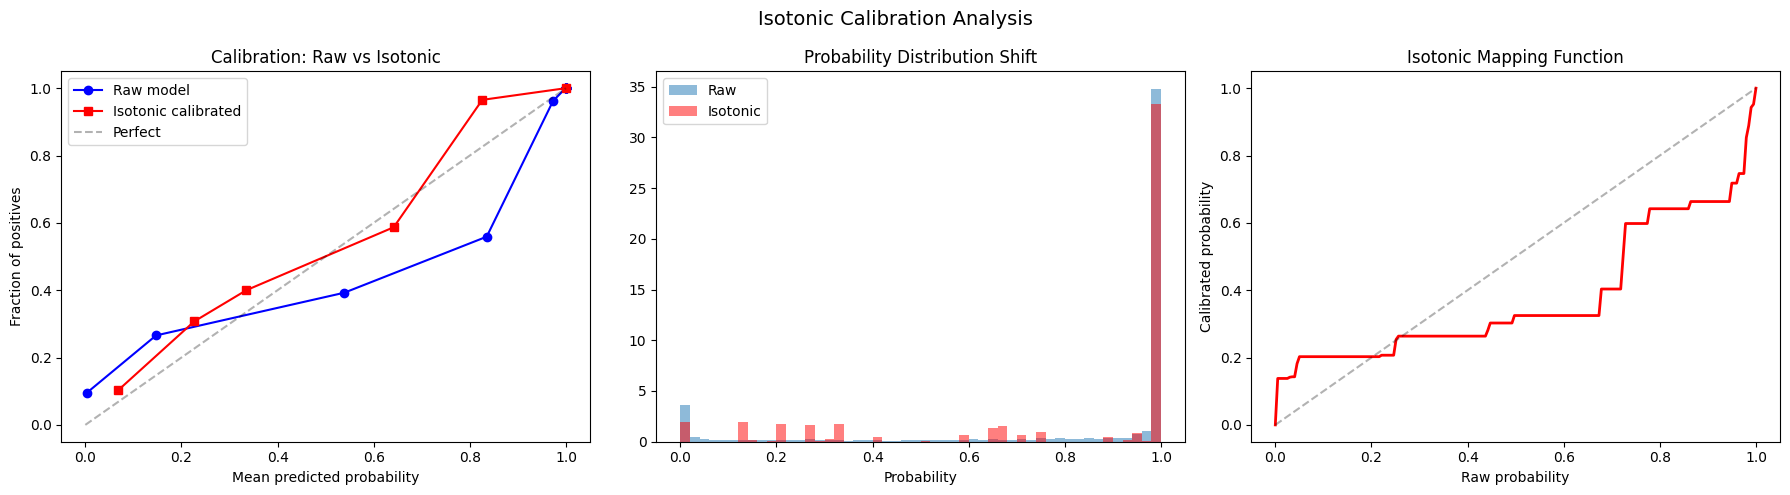

AUC (raw):      0.9708
AUC (isotonic): 0.9704
AUC delta:      -0.0004

F1-optimal threshold (raw):      0.8029 (F1=0.9540)
F1-optimal threshold (isotonic): 0.6453 (F1=0.9530)

→ Isotonic calibration shifts threshold from 0.803 to 0.645
  This explains the production threshold of 0.0494


In [23]:
# Replicate production isotonic calibration in notebook
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.isotonic import IsotonicRegression

# Use the pruned/optuna classifier for calibration analysis
if not final_is_regression:
    cal_model_base = final_model
    cal_features = FEATURE_COLS_PRUNED
else:
    # Use the pruned classifier even if regression won
    cal_model_base = pruned_model
    cal_features = FEATURE_COLS_PRUNED

# Split val into calibration-fit and calibration-eval (same as production code)
n_cal = len(df_val) // 2
X_cal_fit = df_val[cal_features].values[:n_cal].astype(float)
y_cal_fit = y_val[:n_cal]
X_cal_eval = df_val[cal_features].values[n_cal:].astype(float)
y_cal_eval = y_val[n_cal:]

# Raw probabilities
proba_raw_fit = cal_model_base.predict_proba(X_cal_fit)[:, 1]
proba_raw_eval = cal_model_base.predict_proba(X_cal_eval)[:, 1]

# Fit isotonic regression on raw probabilities
iso_reg = IsotonicRegression(out_of_bounds='clip')
iso_reg.fit(proba_raw_fit, y_cal_fit)
proba_iso_eval = iso_reg.predict(proba_raw_eval)

# Compare calibration curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Calibration curve: raw vs isotonic
prob_true_raw, prob_pred_raw = calibration_curve(y_cal_eval, proba_raw_eval, n_bins=15, strategy='quantile')
prob_true_iso, prob_pred_iso = calibration_curve(y_cal_eval, proba_iso_eval, n_bins=15, strategy='quantile')
axes[0].plot(prob_pred_raw, prob_true_raw, 'bo-', label='Raw model')
axes[0].plot(prob_pred_iso, prob_true_iso, 'rs-', label='Isotonic calibrated')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect')
axes[0].set_xlabel('Mean predicted probability')
axes[0].set_ylabel('Fraction of positives')
axes[0].set_title('Calibration: Raw vs Isotonic')
axes[0].legend()

# Probability distribution shift
axes[1].hist(proba_raw_eval, bins=50, alpha=0.5, label='Raw', density=True)
axes[1].hist(proba_iso_eval, bins=50, alpha=0.5, label='Isotonic', density=True, color='red')
axes[1].set_xlabel('Probability')
axes[1].set_title('Probability Distribution Shift')
axes[1].legend()

# Isotonic mapping function
x_grid = np.linspace(0, 1, 200)
y_grid = iso_reg.predict(x_grid)
axes[2].plot(x_grid, y_grid, 'r-', lw=2)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[2].set_xlabel('Raw probability')
axes[2].set_ylabel('Calibrated probability')
axes[2].set_title('Isotonic Mapping Function')

plt.suptitle('Isotonic Calibration Analysis', fontsize=14)
plt.tight_layout()
plt.show()

# AUC comparison
auc_raw = roc_auc_score(y_cal_eval, proba_raw_eval)
auc_iso = roc_auc_score(y_cal_eval, proba_iso_eval)
print(f'AUC (raw):      {auc_raw:.4f}')
print(f'AUC (isotonic): {auc_iso:.4f}')
print(f'AUC delta:      {auc_iso - auc_raw:+.4f}')

# F1-optimal thresholds: raw vs isotonic
thresh_raw, f1_raw = find_f1_threshold(y_cal_eval, proba_raw_eval)
thresh_iso, f1_iso = find_f1_threshold(y_cal_eval, proba_iso_eval)
print(f'\nF1-optimal threshold (raw):      {thresh_raw:.4f} (F1={f1_raw:.4f})')
print(f'F1-optimal threshold (isotonic): {thresh_iso:.4f} (F1={f1_iso:.4f})')
print(f'\n→ Isotonic calibration shifts threshold from {thresh_raw:.3f} to {thresh_iso:.3f}')
print(f'  This explains the production threshold of {meta["threshold"]:.4f}')

## Section 9: Dual-Output Approach (Regression + Classifier Gate)

If regression wins again with 75 features, consider a **dual-output** architecture:
- **Regression head**: predicts `delta_indoor_8h` → continuous cooling intensity (how much pre-cooling is needed)
- **Classifier gate**: binary on/off decision with balanced F1 threshold

The idea: use the classifier's balanced threshold as a gate, and the regression output
to modulate cooling intensity. This combines the best of both approaches:
- Classifier provides a well-calibrated binary decision (no threshold collapse)
- Regression provides continuous cooling magnitude for proportional control

In [24]:
# Dual-output approach: combine classifier gate + regression intensity
# Train both models on the same feature set, then combine decisions

# 1. Classifier gate (pruned model, F1-optimal threshold)
cls_gate_model = pruned_model  # already trained
cls_proba_val = cls_gate_model.predict_proba(df_val[FEATURE_COLS_PRUNED].values.astype(float))[:, 1]
cls_thresh_f1, _ = find_f1_threshold(y_val, cls_proba_val)
cls_gate = (cls_proba_val >= cls_thresh_f1).astype(int)

# 2. Regression intensity (regression model on common indices)
# Align regression output to same validation indices
reg_common_idx = df_val.index.intersection(df_val_r.index)
reg_pred_common = reg_model.predict(df.loc[reg_common_idx, FEATURE_COLS_PRUNED].values.astype(float))
indoor_common = df.loc[reg_common_idx, 'indoor_temp'].values
pred_max_common = indoor_common + reg_pred_common
y_true_common = df.loc[reg_common_idx, 'label'].values.astype(int)

# Classifier gate on same indices
cls_proba_common = cls_gate_model.predict_proba(df.loc[reg_common_idx, FEATURE_COLS_PRUNED].values.astype(float))[:, 1]
cls_gate_common = (cls_proba_common >= cls_thresh_f1).astype(int)

# Regression binary on same indices
reg_binary_common = (pred_max_common > reg_thresh).astype(int)

# 3. Dual-output strategies
# Strategy A: classifier gate AND regression overshoot (conservative)
dual_conservative = (cls_gate_common & reg_binary_common).astype(int)
# Strategy B: classifier gate OR regression overshoot (aggressive)
dual_aggressive = (cls_gate_common | reg_binary_common).astype(int)
# Strategy C: classifier gate × regression intensity (weighted)
# Use classifier as gate, regression delta as intensity
overshoot_delta = np.clip(pred_max_common - COOLING_TARGET, 0, None)
dual_weighted_score = cls_proba_common * overshoot_delta  # probability × magnitude
dual_weighted_thresh, dual_weighted_f1 = find_f1_threshold(y_true_common, dual_weighted_score)
dual_weighted = (dual_weighted_score >= dual_weighted_thresh).astype(int)

# Compare all approaches
approaches = {
    'Classifier only (F1)': cls_gate_common,
    'Regression only': reg_binary_common,
    'Dual: AND (conservative)': dual_conservative,
    'Dual: OR (aggressive)': dual_aggressive,
    'Dual: weighted (P×Δ)': dual_weighted,
}

print(f'=== DUAL-OUTPUT APPROACH COMPARISON (n={len(reg_common_idx)}) ===')
print(f'{"Approach":<30s} {"AUC":>8s} {"F1":>8s} {"Prec":>8s} {"Rec":>8s} {"Pos%":>8s}')
print('-' * 72)

for name, preds in approaches.items():
    if name == 'Dual: weighted (P×Δ)':
        a = roc_auc_score(y_true_common, dual_weighted_score)
    elif name == 'Classifier only (F1)':
        a = roc_auc_score(y_true_common, cls_proba_common)
    elif name == 'Regression only':
        a = roc_auc_score(y_true_common, pred_max_common)
    else:
        a = float('nan')  # AUC not meaningful for binary combinations
    
    f1_v = f1_score(y_true_common, preds)
    p_v = precision_score(y_true_common, preds)
    r_v = recall_score(y_true_common, preds)
    pos_v = preds.mean()
    print(f'{name:<30s} {a:8.4f} {f1_v:8.4f} {p_v:8.4f} {r_v:8.4f} {pos_v:8.1%}')

print(f'\nTrue positive rate: {y_true_common.mean():.1%}')
print(f'\nClassifier gate threshold: {cls_thresh_f1:.4f}')
print(f'Regression overshoot threshold: {reg_thresh:.2f}°C')
print(f'Weighted (P×Δ) threshold: {dual_weighted_thresh:.4f}')

=== DUAL-OUTPUT APPROACH COMPARISON (n=11938) ===
Approach                            AUC       F1     Prec      Rec     Pos%
------------------------------------------------------------------------
Classifier only (F1)             0.9431   0.9187   0.9488   0.8904    70.0%
Regression only                  0.9515   0.9344   0.9295   0.9393    75.3%
Dual: AND (conservative)            nan   0.9221   0.9747   0.8748    66.9%
Dual: OR (aggressive)               nan   0.9309   0.9081   0.9549    78.4%
Dual: weighted (P×Δ)             0.9513   0.9349   0.9389   0.9309    73.9%

True positive rate: 74.6%

Classifier gate threshold: 0.7733
Regression overshoot threshold: 23.01°C
Weighted (P×Δ) threshold: 0.0100


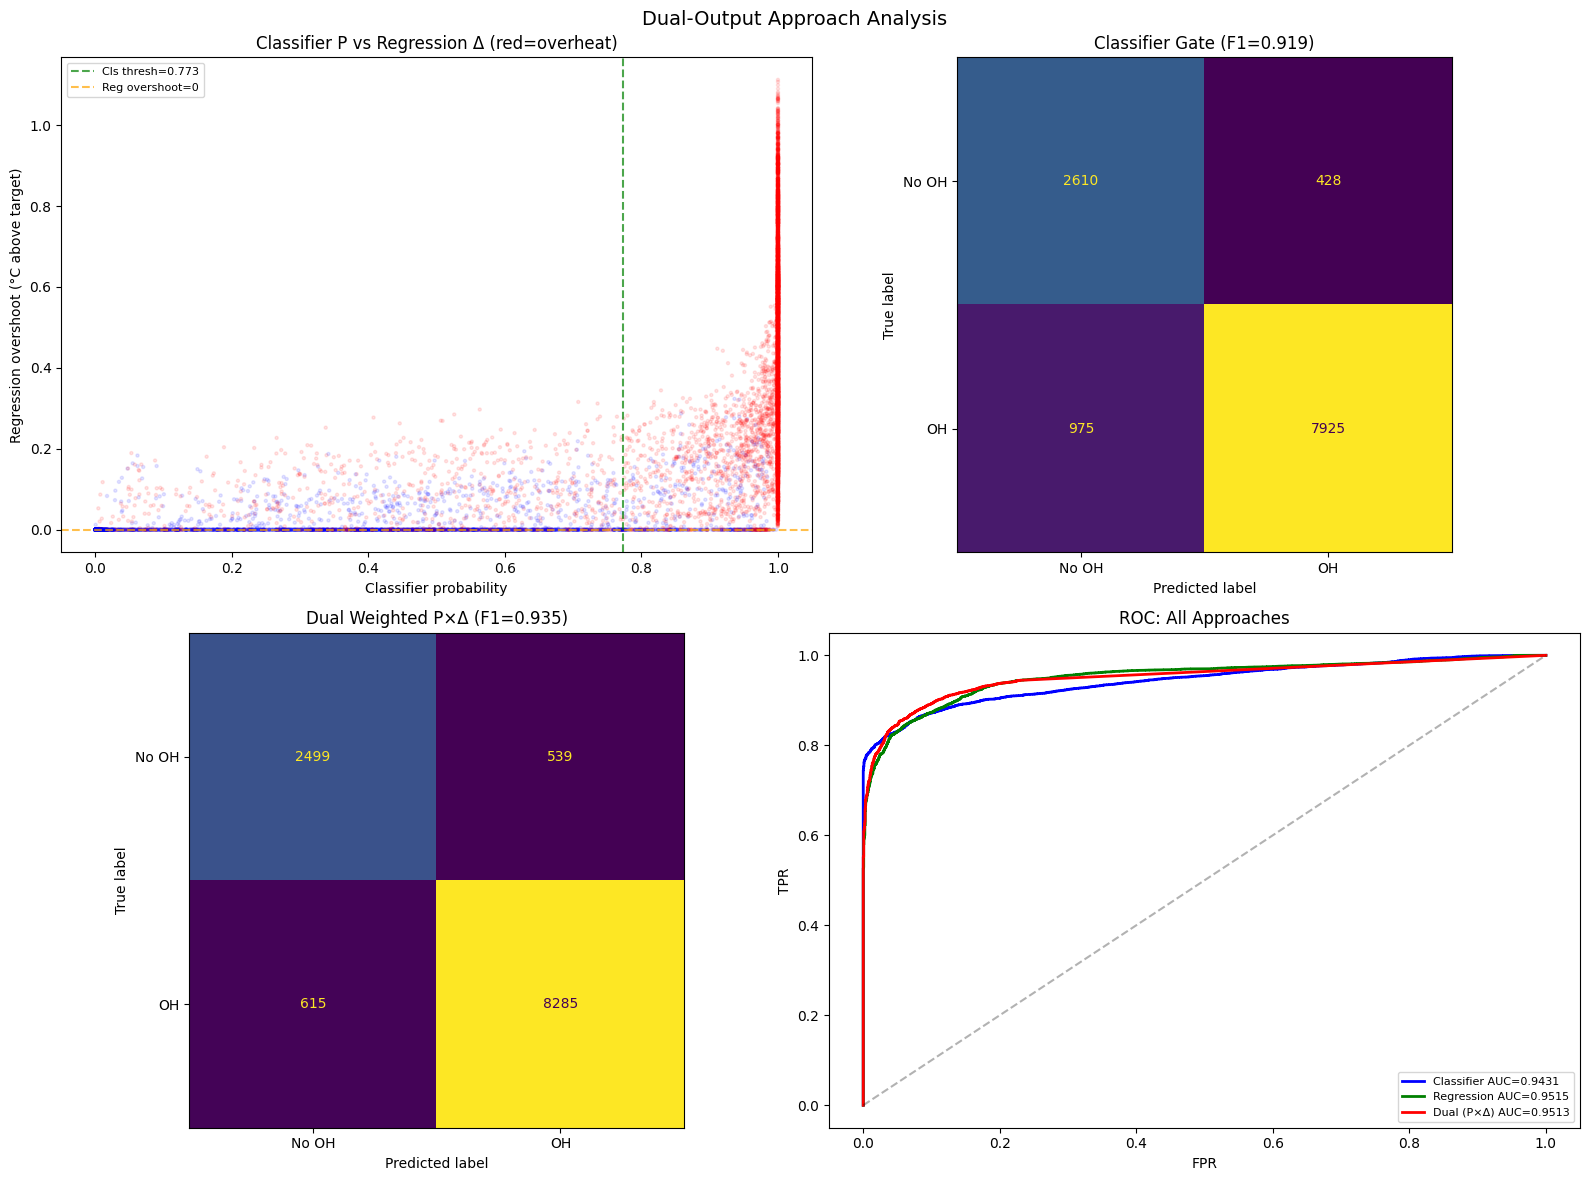

Agreement rate: 88.5% (10567/11938)
Disagreements: 1371 samples
  Classifier correct, regression wrong: 571
  Regression correct, classifier wrong: 800
  Both wrong: 0


In [25]:
# Dual-output diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Classifier probability vs regression delta (colored by true label)
scatter_colors = ['blue' if y == 0 else 'red' for y in y_true_common]
axes[0, 0].scatter(cls_proba_common, overshoot_delta, c=scatter_colors, alpha=0.1, s=5)
axes[0, 0].axvline(cls_thresh_f1, color='green', ls='--', alpha=0.7, label=f'Cls thresh={cls_thresh_f1:.3f}')
axes[0, 0].axhline(0, color='orange', ls='--', alpha=0.7, label='Reg overshoot=0')
axes[0, 0].set_xlabel('Classifier probability')
axes[0, 0].set_ylabel('Regression overshoot (°C above target)')
axes[0, 0].set_title('Classifier P vs Regression Δ (red=overheat)')
axes[0, 0].legend(fontsize=8)

# 2. Confusion matrix comparison: F1 classifier vs dual-weighted
from sklearn.metrics import ConfusionMatrixDisplay
cm_cls = confusion_matrix(y_true_common, cls_gate_common)
ConfusionMatrixDisplay(cm_cls, display_labels=['No OH', 'OH']).plot(ax=axes[0, 1], colorbar=False)
axes[0, 1].set_title(f'Classifier Gate (F1={f1_score(y_true_common, cls_gate_common):.3f})')

# 3. Dual weighted confusion matrix
cm_dual = confusion_matrix(y_true_common, dual_weighted)
ConfusionMatrixDisplay(cm_dual, display_labels=['No OH', 'OH']).plot(ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title(f'Dual Weighted P×Δ (F1={f1_score(y_true_common, dual_weighted):.3f})')

# 4. ROC overlay: classifier vs regression vs dual-weighted
fpr_cls, tpr_cls, _ = roc_curve(y_true_common, cls_proba_common)
fpr_reg2, tpr_reg2, _ = roc_curve(y_true_common, pred_max_common)
fpr_dual, tpr_dual, _ = roc_curve(y_true_common, dual_weighted_score)
axes[1, 1].plot(fpr_cls, tpr_cls, 'b-', lw=2, label=f'Classifier AUC={roc_auc_score(y_true_common, cls_proba_common):.4f}')
axes[1, 1].plot(fpr_reg2, tpr_reg2, 'g-', lw=2, label=f'Regression AUC={roc_auc_score(y_true_common, pred_max_common):.4f}')
axes[1, 1].plot(fpr_dual, tpr_dual, 'r-', lw=2, label=f'Dual (P×Δ) AUC={roc_auc_score(y_true_common, dual_weighted_score):.4f}')
axes[1, 1].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[1, 1].set_xlabel('FPR'); axes[1, 1].set_ylabel('TPR')
axes[1, 1].set_title('ROC: All Approaches')
axes[1, 1].legend(fontsize=8)

plt.suptitle('Dual-Output Approach Analysis', fontsize=14)
plt.tight_layout()
plt.show()

# Disagreement analysis: where do classifier and regression disagree?
agree = (cls_gate_common == reg_binary_common)
disagree = ~agree
print(f'Agreement rate: {agree.mean():.1%} ({agree.sum()}/{len(agree)})')
print(f'Disagreements: {disagree.sum()} samples')

if disagree.sum() > 0:
    # Among disagreements, who is right?
    cls_right_reg_wrong = ((cls_gate_common == y_true_common) & disagree).sum()
    reg_right_cls_wrong = ((reg_binary_common == y_true_common) & disagree).sum()
    both_wrong = (disagree & (cls_gate_common != y_true_common) & (reg_binary_common != y_true_common)).sum()
    print(f'  Classifier correct, regression wrong: {cls_right_reg_wrong}')
    print(f'  Regression correct, classifier wrong: {reg_right_cls_wrong}')
    print(f'  Both wrong: {both_wrong}')

## Section 10: Final Summary

In [26]:
# Final summary table
print('=' * 75)
print('COOLING ML MODEL ANALYSIS — FINAL SUMMARY (75-feature, F1 threshold)')
print('=' * 75)
print(f'\n{"Stage":<35s} {"AUC":>8s} {"F1":>8s} {"Features":>10s} {"Threshold":>10s}')
print('-' * 75)
print(f'{"Production (metadata)":<35s} {meta["roc_auc"]:8.4f} {"—":>8s} {meta["n_features"]:10d} {meta["threshold"]:10.4f}')
print(f'{"Baseline (75 features, F1)":<35s} {auc_base:8.4f} {f1_base:8.4f} {len(FEATURE_COLS_BASELINE):10d} {thresh_base:10.4f}')
print(f'{"After pruning":<35s} {current_auc:8.4f} {f1_pruned:8.4f} {len(FEATURE_COLS_PRUNED):10d} {thresh_pruned:10.4f}')
print(f'{"Regression alternative":<35s} {auc_reg:8.4f} {f1_reg:8.4f} {len(FEATURE_COLS_PRUNED):10d} {reg_thresh:10.2f}°C')
print(f'{"Final (Optuna-tuned)":<35s} {final_auc:8.4f} {final_f1:8.4f} {len(FEATURE_COLS_PRUNED):10d} {final_thresh:10.4f}')

# Dual-output results
dual_f1 = f1_score(y_true_common, dual_weighted)
dual_auc = roc_auc_score(y_true_common, dual_weighted_score)
print(f'{"Dual-output (P×Δ)":<35s} {dual_auc:8.4f} {dual_f1:8.4f} {len(FEATURE_COLS_PRUNED):10d} {dual_weighted_thresh:10.4f}')
print('-' * 75)

print(f'\nBest single approach: {best_approach.upper()}')
print(f'AUC improvement vs production: {meta["roc_auc"]:.4f} → {final_auc:.4f} ({final_auc - meta["roc_auc"]:+.4f})')
print(f'Features: {meta["n_features"]} → {len(FEATURE_COLS_PRUNED)} (after pruning)')

# Pruned features
dropped = [f for f in FEATURE_COLS_BASELINE if f not in FEATURE_COLS_PRUNED]
if dropped:
    print(f'\nDropped during pruning ({len(dropped)}): {dropped}')

# Final quality assessment
print(f'\n--- THRESHOLD QUALITY ASSESSMENT ---')
print(f'F1 threshold: {final_thresh:.4f} ({"✅ BALANCED" if 0.3 <= final_thresh <= 0.7 else "⚠️ outside 0.3-0.7 range"})')
y_pred_final = (y_proba_final >= final_thresh).astype(int)
final_precision = precision_score(y_true_final, y_pred_final)
final_recall = recall_score(y_true_final, y_pred_final)
print(f'Precision: {final_precision:.4f} ({"✅" if final_precision >= 0.85 else "⚠️"} target ≥ 0.85)')
print(f'Recall:    {final_recall:.4f} ({"✅" if final_recall >= 0.85 else "⚠️"} target ≥ 0.85)')
print(f'Pred pos rate: {y_pred_final.mean():.1%} (true: {y_true_final.mean():.1%})')

print(f'\n--- RECOMMENDATION ---')
if best_approach == 'regression':
    print('Regression approach wins. Consider dual-output architecture:')
    print('  1. Classifier gate with F1 threshold for balanced on/off decision')
    print('  2. Regression output for proportional cooling intensity')
    print('  3. Final decision: activate pre-cooling when classifier gate=1,')
    print('     with intensity proportional to predicted temperature overshoot')
else:
    print('Classifier approach wins with F1 threshold.')
    print('The balanced threshold provides good precision/recall trade-off.')
    print('Consider adding regression as secondary signal for cooling intensity.')

COOLING ML MODEL ANALYSIS — FINAL SUMMARY (75-feature, F1 threshold)

Stage                                    AUC       F1   Features  Threshold
---------------------------------------------------------------------------
Production (metadata)                 0.9771        —         75     0.0494
Baseline (75 features, F1)            0.9434   0.9191         75     0.7733
After pruning                         0.9434   0.9191         75     0.7733
Regression alternative                0.9520   0.9344         75      23.01°C
Final (Optuna-tuned)                  0.9586   0.9365         75    22.9899
Dual-output (P×Δ)                     0.9513   0.9349         75     0.0100
---------------------------------------------------------------------------

Best single approach: REGRESSION
AUC improvement vs production: 0.9771 → 0.9586 (-0.0185)
Features: 75 → 75 (after pruning)

--- THRESHOLD QUALITY ASSESSMENT ---
F1 threshold: 22.9899 (⚠️ outside 0.3-0.7 range)
Precision: 0.9412 (✅ target ≥ 0.